In [27]:
import re
import numpy as np
import pandas as pd
import tabata as tbt
import ipywidgets as widgets
import matplotlib.pyplot as plt
%matplotlib inline

import Projet_rectangularisation_vols as m2d 

%reload_ext autoreload
%autoreload 2


In [28]:
# Chargement des données.
datadir = "../Data/cleaned/"
final_file = datadir + "AFL1EB_cleaned_final.h5"
norm_file = datadir + "AFL1EB_normed_alt.h5"
ds = tbt.Opset(final_file)
ds

OPSET '../Data/cleaned/AFL1EB_cleaned_final.h5' de 47 signaux.
        position courante : sigpos  = 0
        variable courante : colname = ALT[m]
        phase surlignée   : phase   = None

In [29]:
ds.plot()

In [30]:
# Ajout d'une référence normalisée à utiliser pour la transformation.

dsn1 = tbt.Opset(norm_file).clean()
for df in ds:
    alt = df["ALT[m]"]
    max_alt = np.max(alt)
    min_alt = np.min(alt)
    altn = (alt-min_alt)/(max_alt-min_alt)
    df["ALTN[-]"] = altn
    dsn1.put(df)
dsn1

OPSET '../Data/cleaned/AFL1EB_normed_alt.h5' de 47 signaux.
        position courante : sigpos  = 46
        variable courante : colname = ALT[m]
        phase surlignée   : phase   = None

In [31]:
df = dsn1.df
x = df["ALTN[-]"]
x.index

DatetimeIndex(['2013-02-20 02:58:00', '2013-02-20 02:58:01',
               '2013-02-20 02:58:02', '2013-02-20 02:58:03',
               '2013-02-20 02:58:04', '2013-02-20 02:58:05',
               '2013-02-20 02:58:06', '2013-02-20 02:58:07',
               '2013-02-20 02:58:08', '2013-02-20 02:58:09',
               ...
               '2013-02-20 05:33:17', '2013-02-20 05:33:18',
               '2013-02-20 05:33:19', '2013-02-20 05:33:20',
               '2013-02-20 05:33:21', '2013-02-20 05:33:22',
               '2013-02-20 05:33:23', '2013-02-20 05:33:24',
               '2013-02-20 05:33:25', '2013-02-20 05:33:26'],
              dtype='datetime64[ns]', name='record_51', length=9327, freq='s')

# Création d'une série d'instants de changement de phase par vol.

* t1 : fin du roulage/début de montée

* t2 : début de croisière

* t3 : fin de croisière

* t4 : début de descente/freinage

* txm : point médian du sommet du vo

In [32]:
import numpy as np

def compute_points(df):
    """Détection automatique des phases caractéristiques d’un vol sur le signal d’altitude (ALT[m])"""

    y = df['ALT[m]'].values
    n = len(y)
    t = np.arange(0, n)

    # Point t1 : fin roulage, début montée
    t1 = np.max(np.argwhere((y < y[0] + 10) & (t < n / 3)))

    # Point t4 : début descente finale
    t4 = np.min(np.argwhere((y < y[-1] + 10) & (t > 2 * n / 3)))

    # Dérivée + lissage
    dy = np.append(np.diff(y), 0)
    k = 3
    dyc = np.convolve(dy, np.ones(2 * k + 1) / (2 * k + 1), mode='same')

    # Altitude max
    mx = np.max(y)
    tx = np.argwhere(y == mx)
    txm = (tx[0] + tx[-1]) / 2  # milieu du plateau haut

    # t2 : fin montée
    t2 = np.min(np.argwhere((y > mx - mx / 10) & (dyc < 2.5) & (t > t1) & (t < txm)))

    # t3 : début descente
    t3 = np.max(np.argwhere((y > mx - mx / 10) & (dyc > -2.5) & (t < t4) & (t > txm)))

    return t1, t2, t3, t4


interactive(children=(IntSlider(value=23, description='record', max=47), Output()), _dom_classes=('widget-inte…

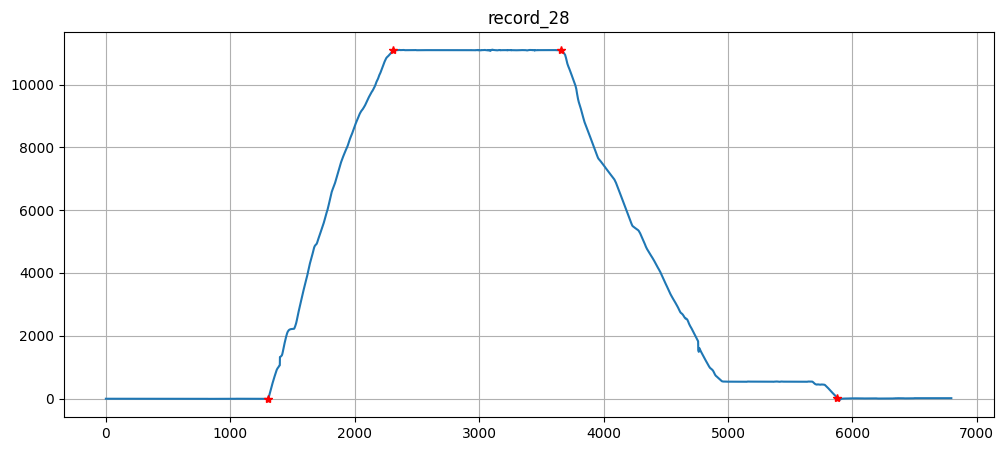

In [33]:
fig, ax = plt.subplots()

@widgets.interact(record=(0,len(ds)))
def update_points(record):
    #[l.remove() for l in ax.lines]
    df = ds[record]
    y = df['ALT[m]'].values
    t1,t2,t3,t4 = m2d.compute_points(df)
    print(record)
    print(t1,t2,t3,t4)

    # Affichage
    ax.cla()
    ax.plot(y)
    ax.plot([t1, t2, t3, t4],[y[t1],y[t2],y[t3], y[t4]],'*r')
    ax.grid()
    ax.set_title(df.index.name)
    display(fig)

In [34]:
L = []
for i,df in enumerate(ds):
    t1,t2,t3,t4 = m2d.compute_points(df)
    
    L.append({'record' : i, 'points' : np.array([t1,t2,t3,t4])})

In [35]:
P = m2d.compute_all_sizes(ds)

In [36]:
NL = P.max(axis=0)


# Empilation des altitudes dans un tableau

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

N_total = 200  # total de points (ex: 50 points/phase × 4 phases)

# calcul des points de découpe pour tous les vols
P = []
for df in ds:
    t1, t2, t3, t4 = compute_points(df) 
    P.append([t1, t2 - t1, t3 - t2, t4 - t3, len(df) - t4])
P = np.array(P)
NL = P.max(axis=0).astype(int)  # nombre de points par phase

In [38]:
# interpolation phase par phase
R = []
for df in ds:
    y = df['ALT[m]'].values
    index = df.index
    t1, t2, t3, t4 = compute_points(df)
    bounds = [0, t1, t2, t3, t4, len(df)-1]
    yn = (y - np.min(y)) / (np.max(y) - np.min(y))  # normalisation entre 0 et 1
    y_interp = []

    for i in range(len(bounds) - 1):
        i0, i1 = bounds[i], bounds[i+1]
        t0 = index[i0].value
        t1 = index[i1].value
        t_new = pd.to_datetime(np.linspace(t0, t1, NL[i]))
        y_new = np.interp(t_new, index[i0:i1], yn[i0:i1])
        y_interp.extend(y_new if i == 0 else y_new[1:])  # évite doublons

    R.append(y_interp)

R = pd.DataFrame(data=np.vstack(R).T)  # format : (points, vols)

In [39]:
R.tail()

,0,1,2,3,4,5,6,7,8,9,...,37,38,39,40,41,42,43,44,45,46
18707,0.00517,0.002928,0.00272,0.002302,0.003808,0.002985,0.003536,0.002848,0.003276,0.00262,...,0.003126,0.00296,0.002795,0.002051,0.002545,0.002872,0.000961,0.002437,0.003086,0.002734
18708,0.00517,0.002928,0.00272,0.002249,0.003748,0.002985,0.003585,0.002848,0.003276,0.00262,...,0.003090,0.00296,0.002795,0.002051,0.002545,0.002872,0.001049,0.002437,0.003086,0.002734
18709,0.00517,0.002928,0.00272,0.002202,0.003705,0.002985,0.003611,0.002848,0.003276,0.00262,...,0.003160,0.00296,0.002795,0.002051,0.002545,0.002872,0.001023,0.002437,0.003086,0.002734
18710,0.00517,0.002928,0.00272,0.002202,0.003705,0.002985,0.003611,0.002848,0.003276,0.00262,...,0.003187,0.00296,0.002795,0.002051,0.002545,0.002872,0.000961,0.002437,0.003086,0.002734
18711,0.00517,0.002928,0.00272,0.002202,0.003705,0.002985,0.003611,0.002848,0.003276,0.00262,...,0.003187,0.00296,0.002795,0.002051,0.002545,0.002872,0.000961,0.002437,0.003086,0.002734


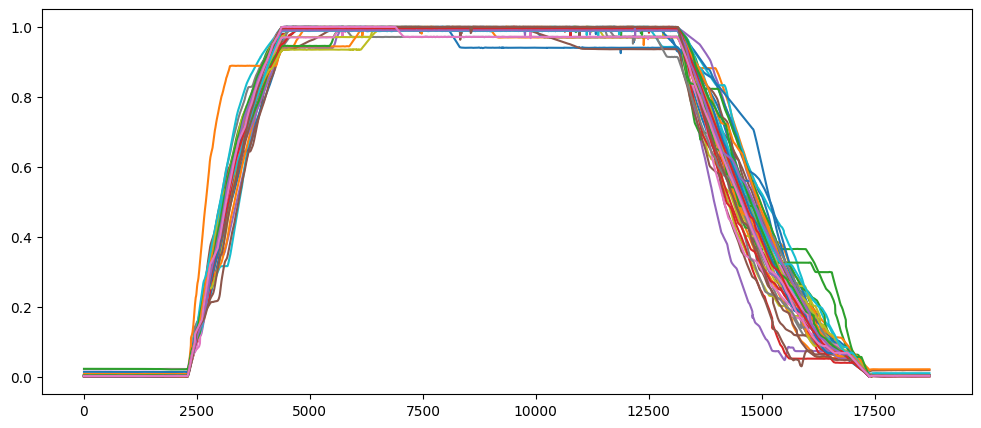

In [40]:
plt.plot(R) ;

In [41]:
# interpolation sans découpe
R_triv = []
for df in ds:
    y = df['ALT[m]'].values
    yn = (y - np.min(y)) / (np.max(y) - np.min(y))
    t0, t1 = df.index[0].value, df.index[-1].value
    t_new = pd.to_datetime(np.linspace(t0, t1, R.shape[0]))
    y_new = np.interp(t_new, df.index, yn)
    R_triv.append(y_new)
R_triv = pd.DataFrame(data=np.vstack(R_triv).T)

In [42]:
R_triv.tail()  

,0,1,2,3,4,5,6,7,8,9,...,37,38,39,40,41,42,43,44,45,46
18707,0.00517,0.002928,0.00272,0.002244,0.003711,0.002985,0.003551,0.002848,0.003276,0.00262,...,0.003079,0.00296,0.002795,0.002051,0.002545,0.002872,0.001055,0.002437,0.003086,0.002734
18708,0.00517,0.002928,0.00272,0.002206,0.003705,0.002985,0.003596,0.002848,0.003276,0.00262,...,0.003135,0.00296,0.002795,0.002051,0.002545,0.002872,0.001041,0.002437,0.003086,0.002734
18709,0.00517,0.002928,0.00272,0.002202,0.003705,0.002985,0.003641,0.002848,0.003276,0.00262,...,0.003187,0.00296,0.002795,0.002051,0.002545,0.002872,0.000975,0.002437,0.003086,0.002735
18710,0.00517,0.002928,0.00272,0.002202,0.003705,0.002985,0.003687,0.002848,0.003276,0.00262,...,0.003187,0.00296,0.002795,0.002051,0.002545,0.002872,0.000961,0.002437,0.003086,0.002792
18711,0.00517,0.002928,0.00272,0.002202,0.003705,0.002985,0.003732,0.002848,0.003276,0.00262,...,0.003187,0.00296,0.002795,0.002051,0.002545,0.002872,0.000961,0.002437,0.003086,0.002848


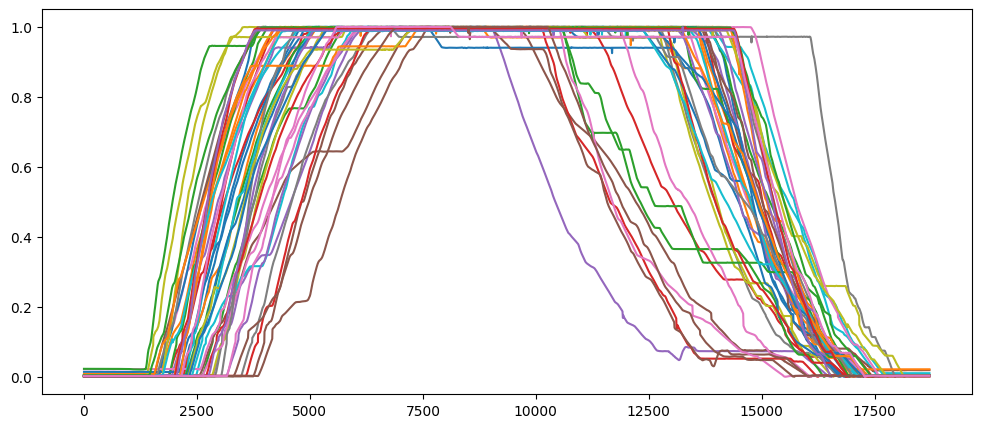

In [43]:
plt.plot(R_triv) ;

interactive(children=(IntSlider(value=0, description='Vol', max=46), IntSlider(value=1, description='Densité x…

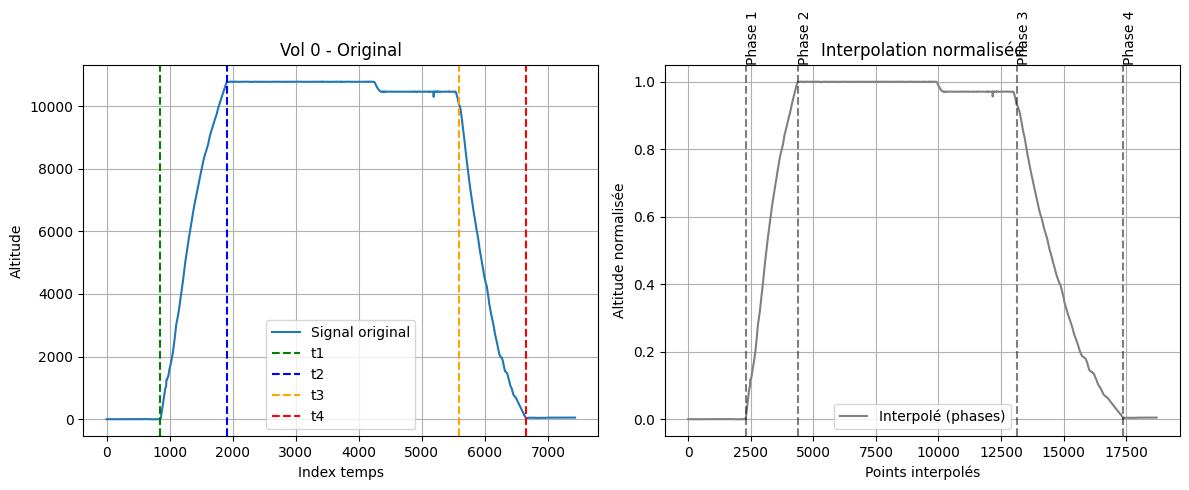

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
import matplotlib
matplotlib.rcParams['figure.figsize'] = (12, 5)

# === Initialisation ===
ds = tbt.Opset(final_file)

# Étape 1 : calcul des points t1–t4 pour tous les vols
P = []
for df in ds:
    t1, t2, t3, t4 = compute_points(df)
    P.append([t1, t2 - t1, t3 - t2, t4 - t3, len(df) - t4])
P = np.array(P)
NL_base = P.max(axis=0).astype(int)  # points de base par phase

# === Visualisation interactive ===

fig, (ax1, ax2) = plt.subplots(1, 2)

@widgets.interact(
    record=widgets.IntSlider(min=0, max=len(ds)-1, step=1, value=0, description='Vol'),
    densite=widgets.IntSlider(min=1, max=5, step=1, value=1, description='Densité x')
)
def update_visualisation(record=0, densite=1):
    ax1.cla()
    ax2.cla()
    
    df = ds[record]
    y = df['ALT[m]'].values
    index = df.index
    t1, t2, t3, t4 = compute_points(df)
    bounds = [0, t1, t2, t3, t4, len(df)-1]

    # Courbe originale
    ax1.plot(y, label='Signal original')
    for t, color, label in zip([t1, t2, t3, t4], ['g', 'b', 'orange', 'r'], ['t1', 't2', 't3', 't4']):
        ax1.axvline(x=t, color=color, linestyle='--', label=label)
    ax1.set_title(f"Vol {record} - Original")
    ax1.set_xlabel("Index temps")
    ax1.set_ylabel("Altitude")
    ax1.legend()
    ax1.grid()

    # Interpolation
    yn = (y - np.min(y)) / (np.max(y) - np.min(y))  # normalisation
    y_interp = []
    NL = (NL_base * densite).astype(int)
    
    for i in range(len(bounds) - 1):
        i0, i1 = bounds[i], bounds[i+1]
        t0 = index[i0].value
        t1_ = index[i1].value
        t_new = pd.to_datetime(np.linspace(t0, t1_, NL[i]))
        y_new = np.interp(t_new, index[i0:i1], yn[i0:i1])
        y_interp.extend(y_new if i == 0 else y_new[1:])  # éviter doublons

    ax2.plot(y_interp, color='gray', label="Interpolé (phases)")
    cum_lengths = np.cumsum(NL)
    for i, x in enumerate(cum_lengths[:-1]):
        ax2.axvline(x=x, linestyle='--', color='k', alpha=0.5)
        ax2.text(x, 1.05, f"Phase {i+1}", rotation=90, verticalalignment='bottom')

    ax2.set_title("Interpolation normalisée")
    ax2.set_xlabel("Points interpolés")
    ax2.set_ylabel("Altitude normalisée")
    ax2.grid()
    ax2.legend()

    fig.tight_layout()
    display(fig)


# Erreur de reconstruction

In [50]:
import numpy as np
import pandas as pd

def reechantillonner_signal(df, freq_hz=1):
    return df['ALT[m]'].resample(f'{int(1e9/freq_hz)}N').mean().interpolate().values

def erreur_reconstruction_global(ds, R_interp, freq_hz=1):
    errors = []
    for i, df in enumerate(ds):
        y_ref = reechantillonner_signal(df, freq_hz)
        duration = df.index[-1] - df.index[0]
        interp_index = pd.date_range(start=df.index[0], periods=len(R_interp[i]),
                                     freq=f'{int(duration.total_seconds()*1e9/len(R_interp[i]))}N')
        y_interp_rs = pd.Series(data=R_interp[i], index=interp_index).resample(f'{int(1e9/freq_hz)}N').mean().interpolate().values
        N = min(len(y_ref), len(y_interp_rs))
        errors.append(np.sqrt(np.mean((y_ref[:N] - y_interp_rs[:N])**2)))
    return np.array(errors)

In [63]:
R_interp = [R.iloc[:, i].values for i in range(R.shape[1])]

# Appel de la fonction avec debug
errors = erreur_reconstruction_global(ds, R_interp, freq_hz=1)

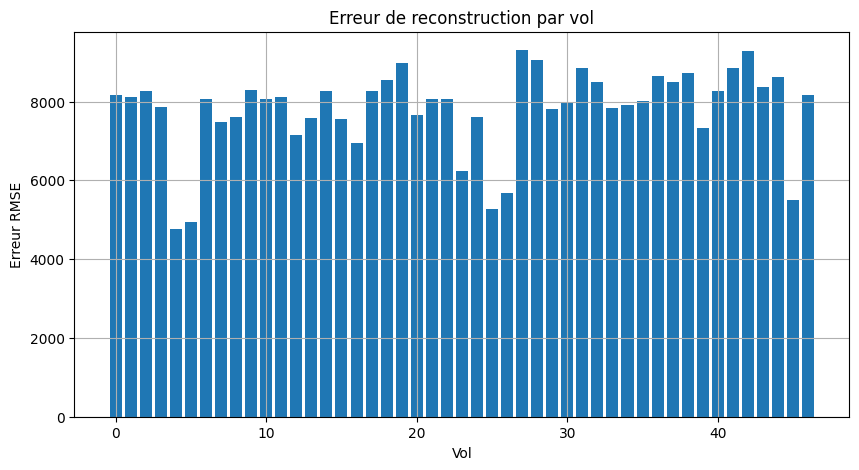

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(range(len(errors)), errors)
plt.xlabel("Vol")
plt.ylabel("Erreur RMSE")
plt.title("Erreur de reconstruction par vol")
plt.grid(True)
plt.show()


# Erreur de syncronisation

In [46]:
# Courbe médiane (ligne par ligne)
median_curve = R.median(axis=1)

# Distance à la courbe médiane (erreur moyenne par vol)
sync_error = R.apply(lambda col: np.mean((col - median_curve)**2), axis=0)

print("Erreur moyenne de synchronisation (méthode phases):", sync_error.mean())

# Pour la méthode triviale
median_curve_triv = R_triv.median(axis=1)
sync_error_triv = R_triv.apply(lambda col: np.mean((col - median_curve_triv)**2), axis=0)

print("Erreur moyenne de synchronisation (méthode triviale):", sync_error_triv.mean())


Erreur moyenne de synchronisation (méthode phases): 0.0013078453514589238
Erreur moyenne de synchronisation (méthode triviale): 0.03109898561269768


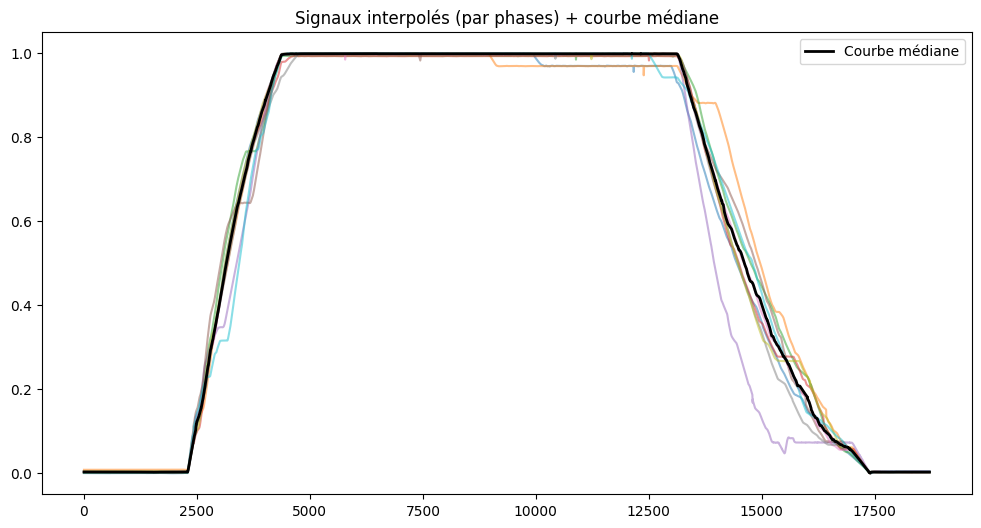

In [47]:
plt.figure(figsize=(12, 6))
for col in R.columns[:10]:  # jusqu'à 10 signaux
    plt.plot(R[col], alpha=0.5)
plt.plot(median_curve, color='black', label='Courbe médiane', linewidth=2)
plt.title("Signaux interpolés (par phases) + courbe médiane")
plt.legend()
plt.show()

# changemant de nombre de points pour chaque phase 

Erreurs de reconstruction par vol :
Vol 1: erreur = 8178.2050
Vol 2: erreur = 8114.2187
Vol 3: erreur = 8279.1399
Vol 4: erreur = 7866.6918
Vol 5: erreur = 4772.2334
Vol 6: erreur = 4952.1210
Vol 7: erreur = 8074.0339
Vol 8: erreur = 7478.9143
Vol 9: erreur = 7595.1914
Vol 10: erreur = 8304.3748
Vol 11: erreur = 8064.3534
Vol 12: erreur = 8105.5835
Vol 13: erreur = 7155.2023
Vol 14: erreur = 7593.0092
Vol 15: erreur = 8267.7172
Vol 16: erreur = 7565.4596
Vol 17: erreur = 6941.6158
Vol 18: erreur = 8260.1360
Vol 19: erreur = 8551.8601
Vol 20: erreur = 8972.4464
Vol 21: erreur = 7668.4374
Vol 22: erreur = 8061.8393
Vol 23: erreur = 8071.4979
Vol 24: erreur = 6230.9519
Vol 25: erreur = 7603.7410
Vol 26: erreur = 5270.5642
Vol 27: erreur = 5691.1935
Vol 28: erreur = 9306.9636
Vol 29: erreur = 9049.3190
Vol 30: erreur = 7809.5169
Vol 31: erreur = 7996.5005
Vol 32: erreur = 8849.3465
Vol 33: erreur = 8503.8651
Vol 34: erreur = 7824.2957
Vol 35: erreur = 7916.0647
Vol 36: erreur = 8023.0822
V

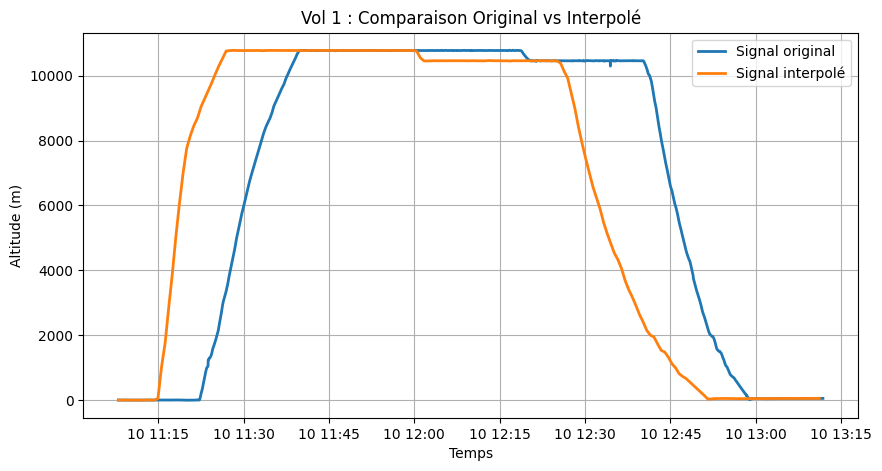

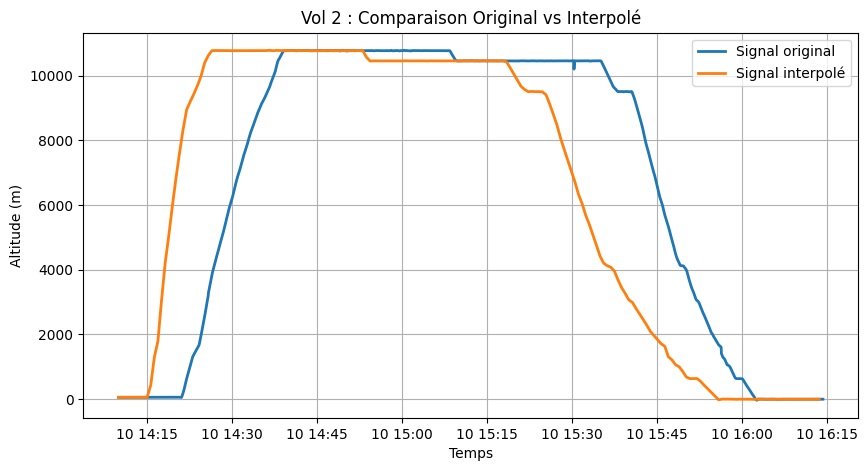

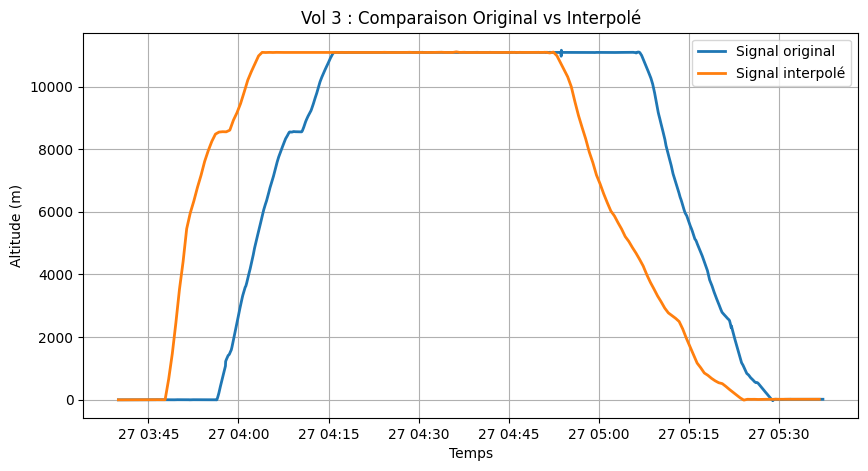

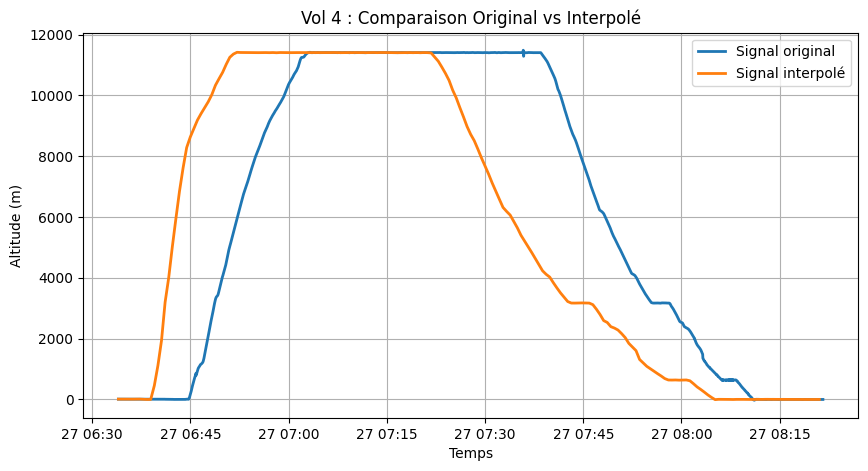

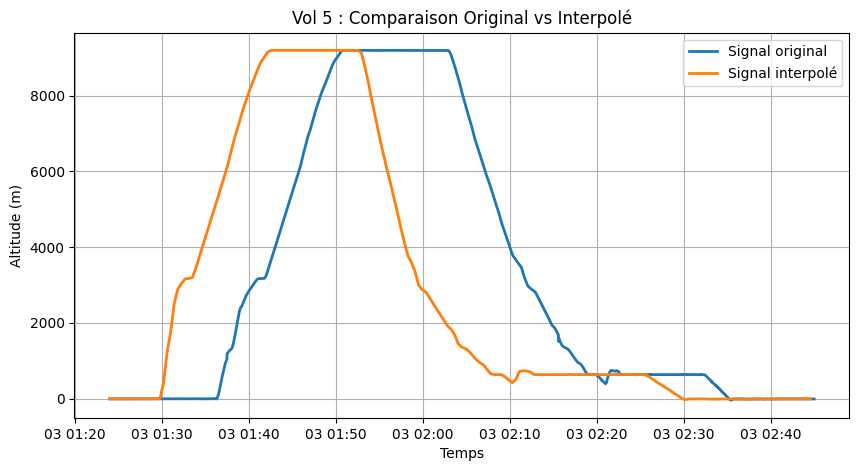

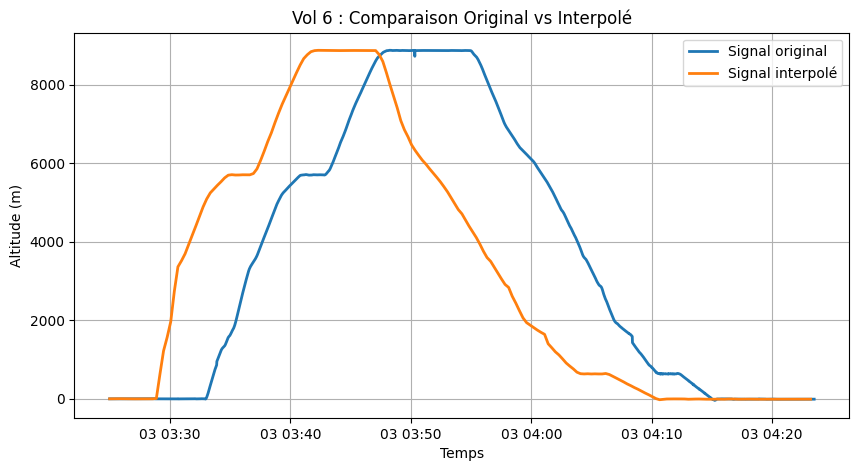

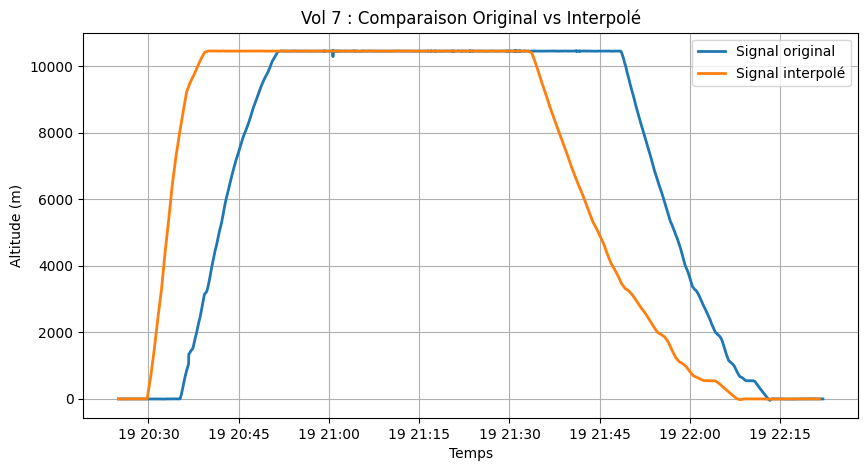

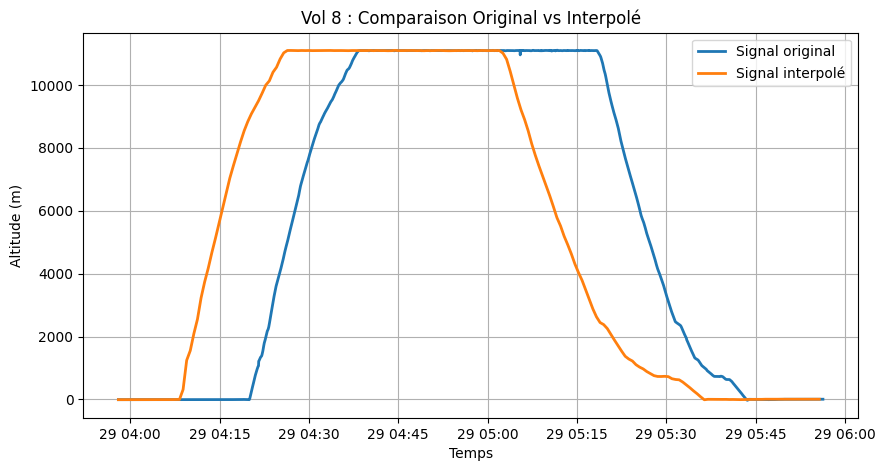

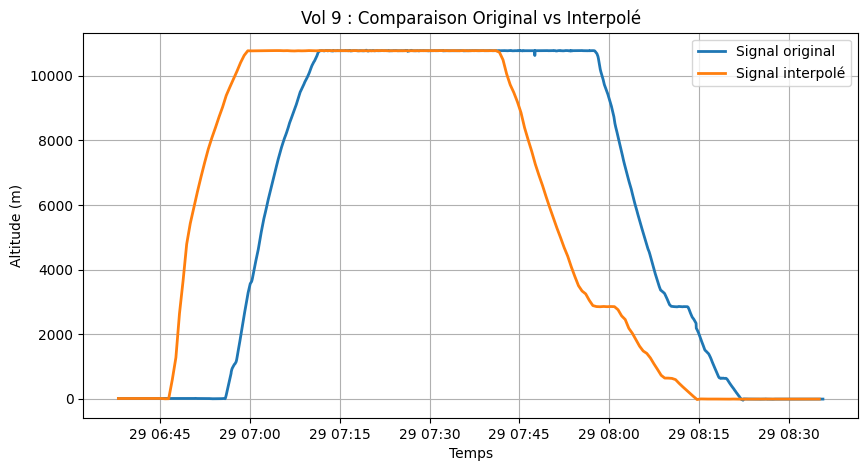

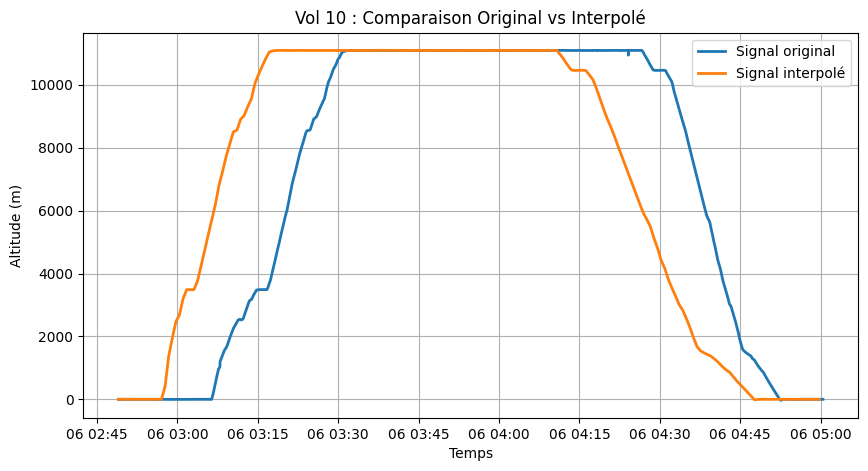

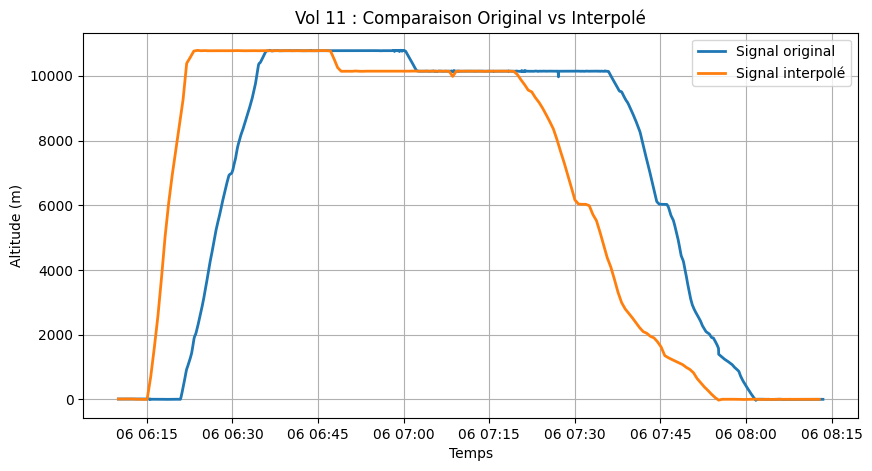

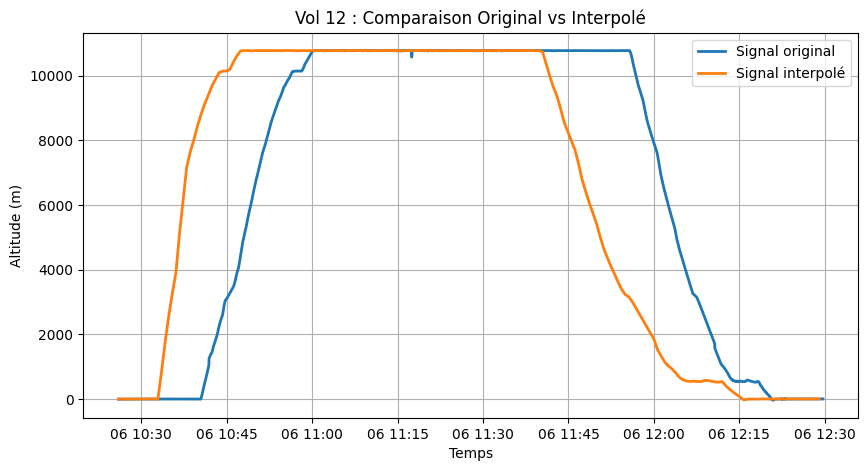

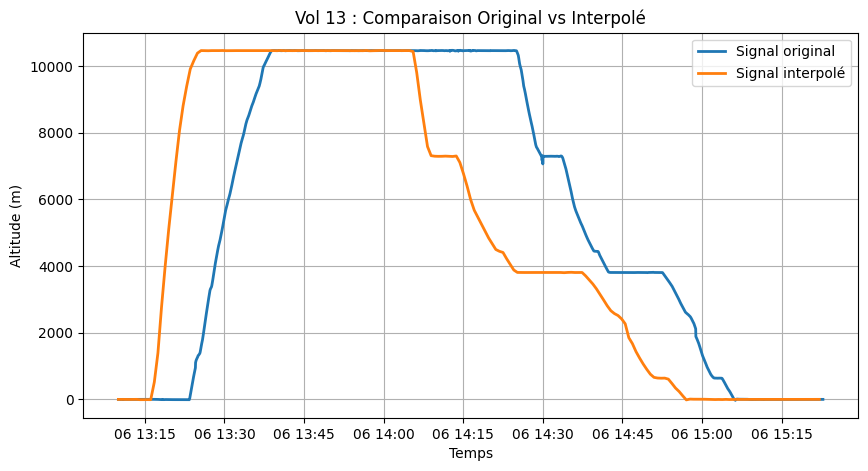

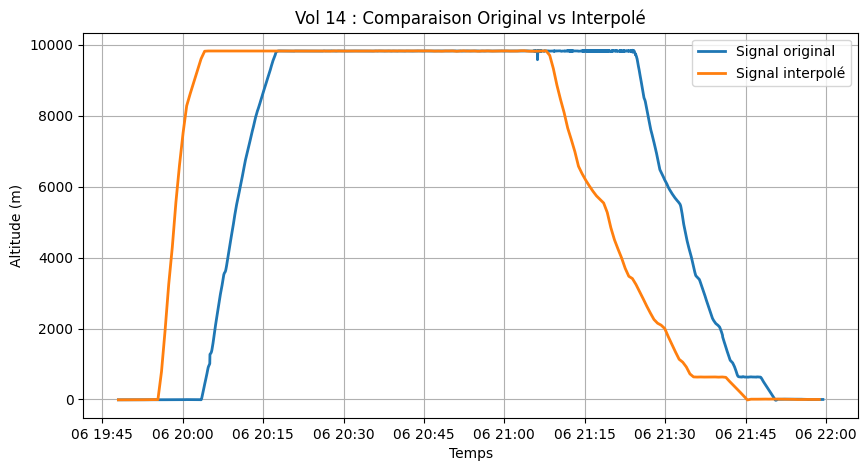

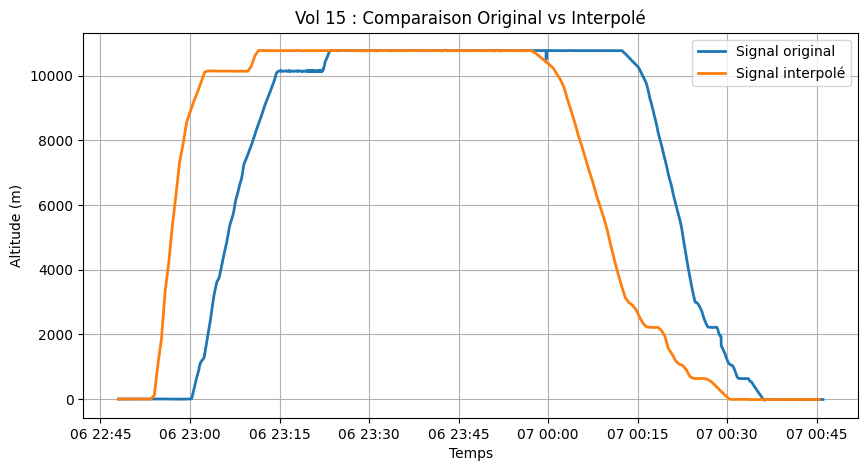

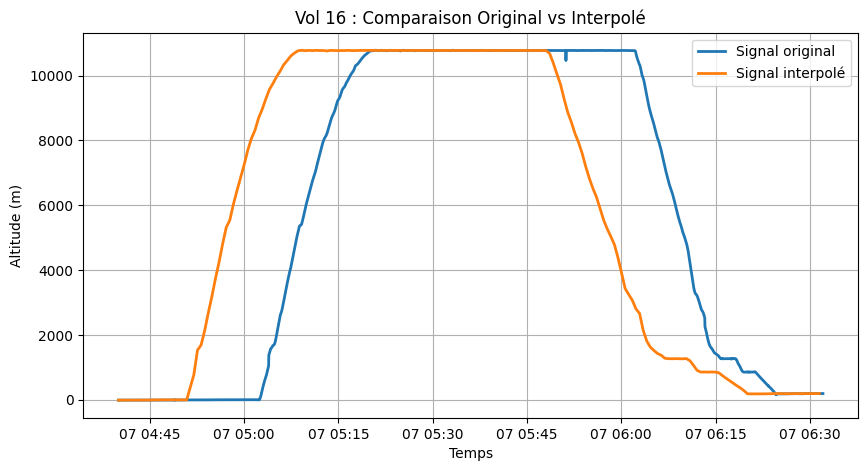

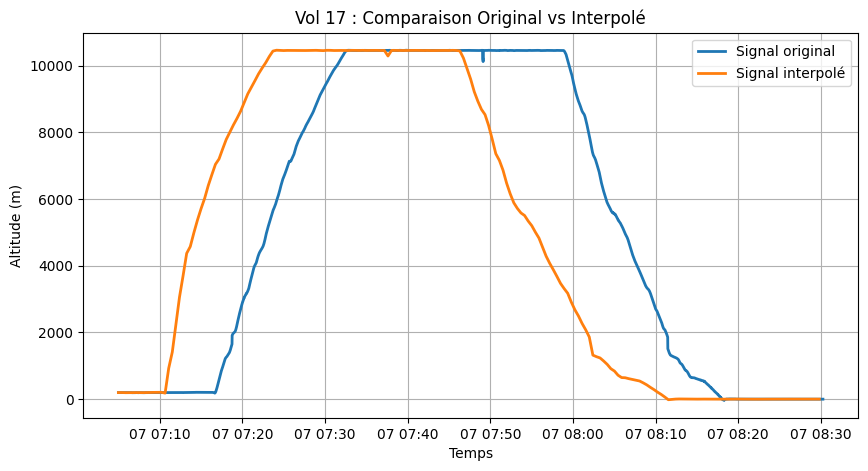

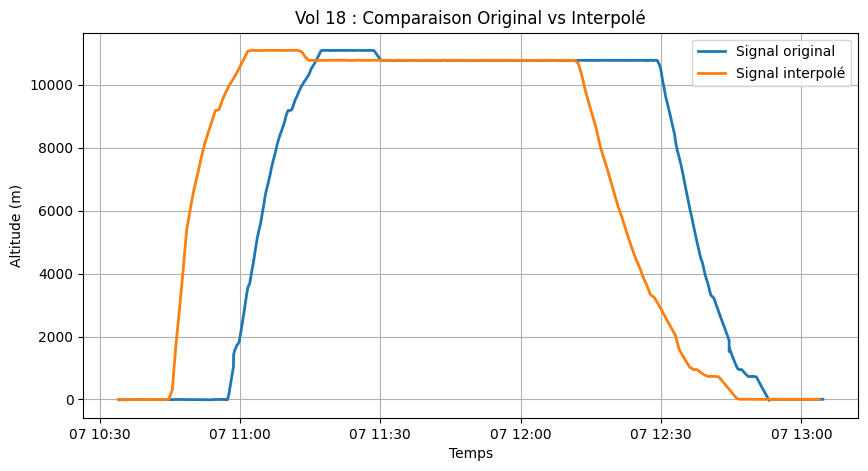

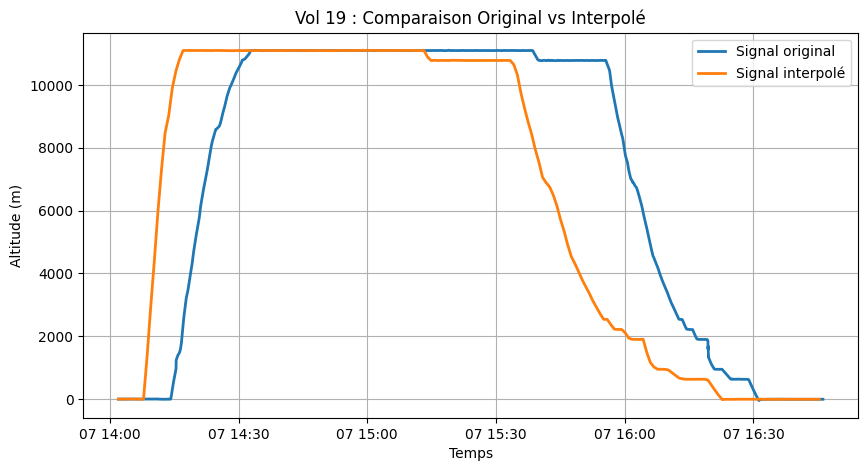

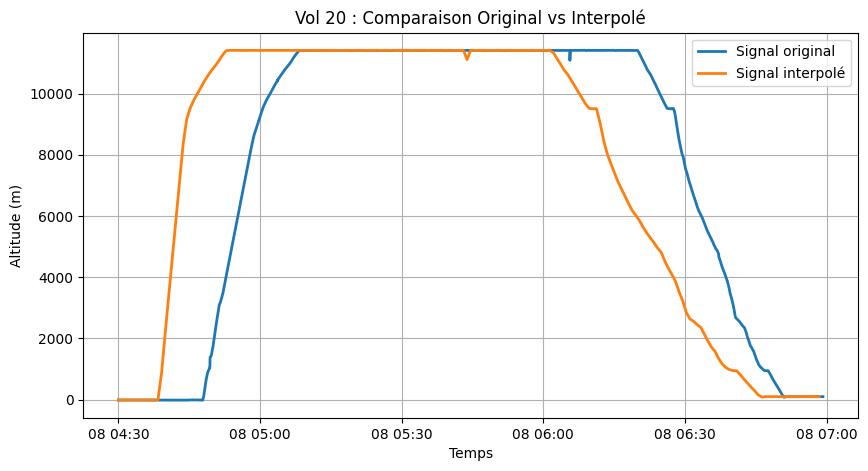

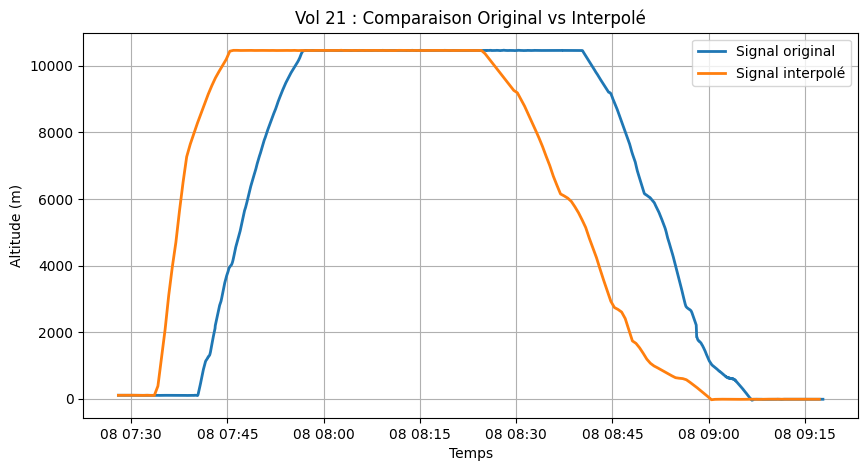

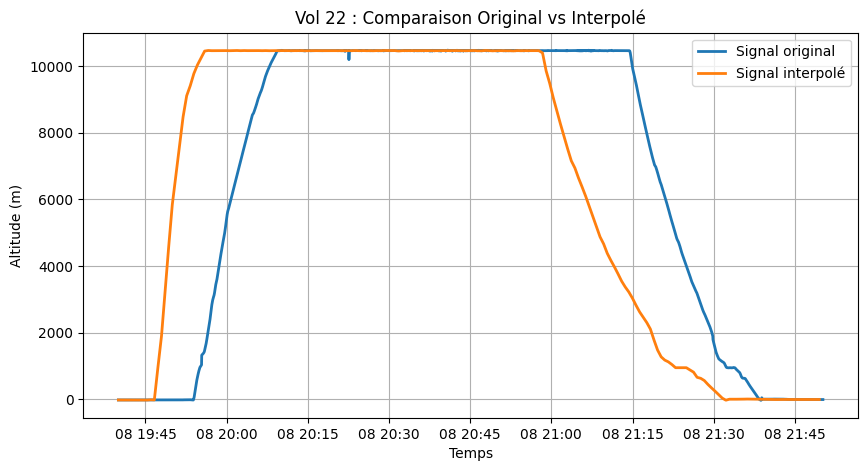

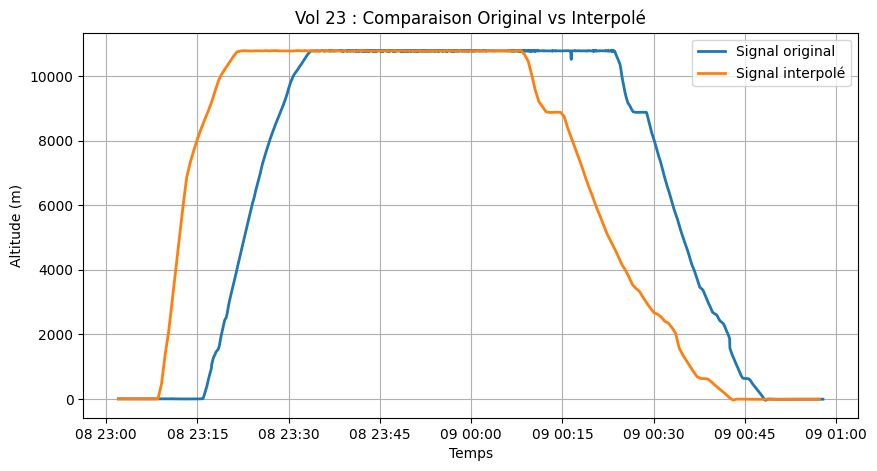

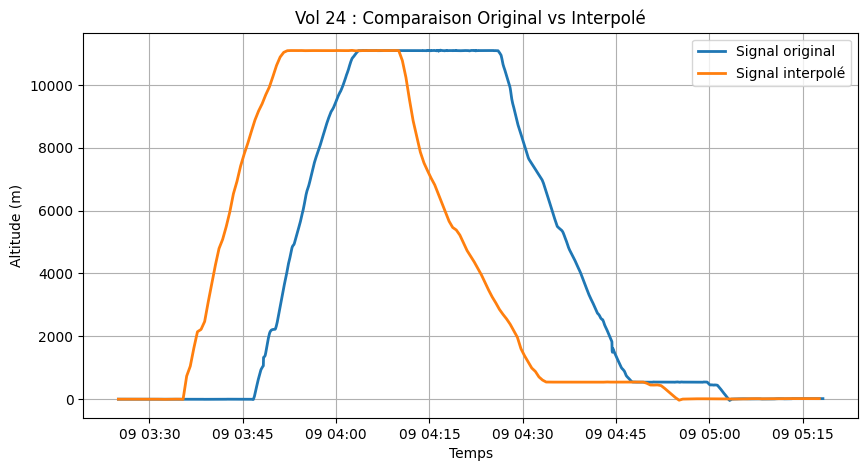

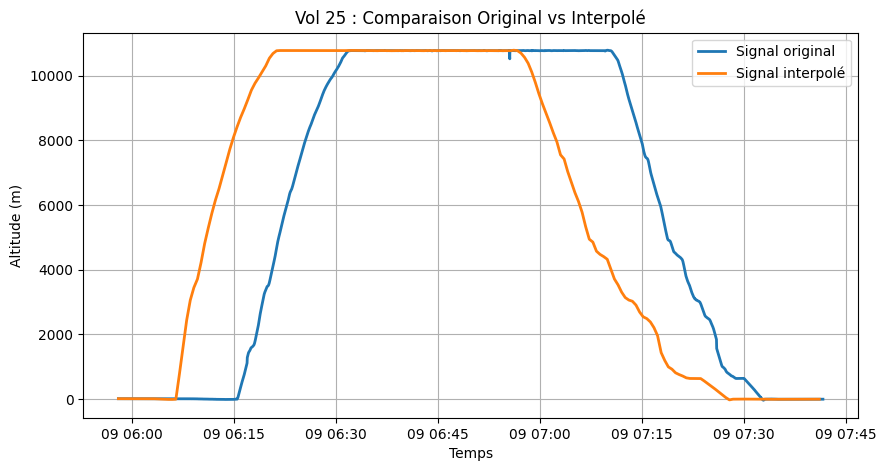

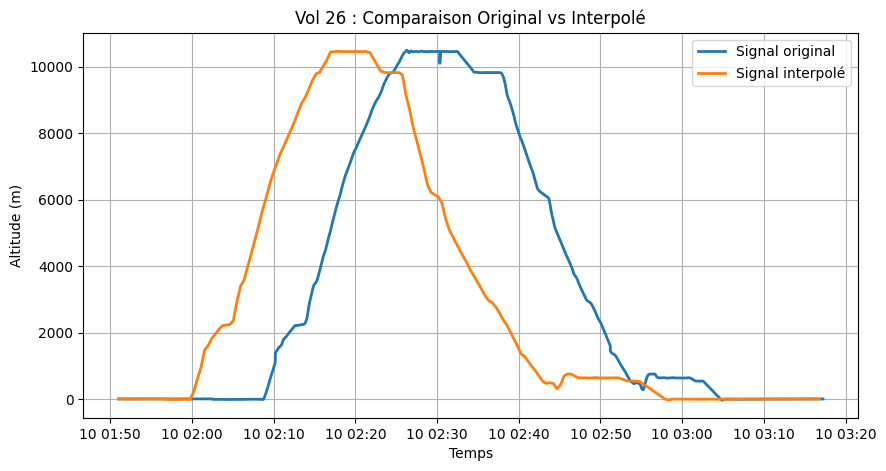

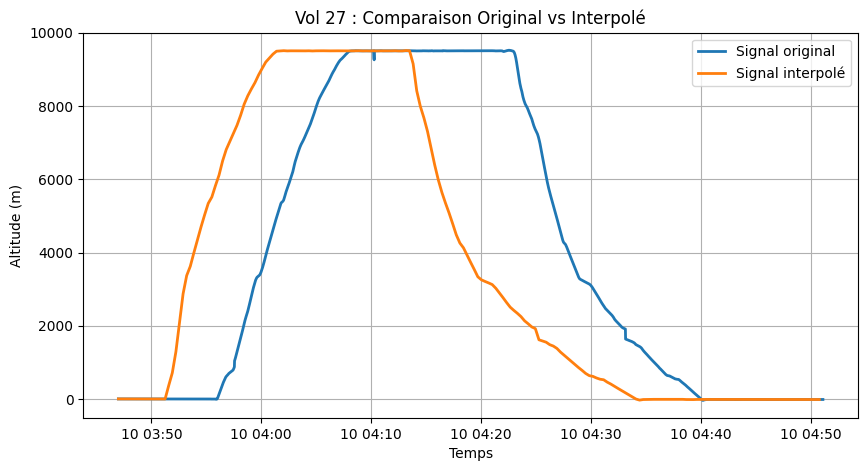

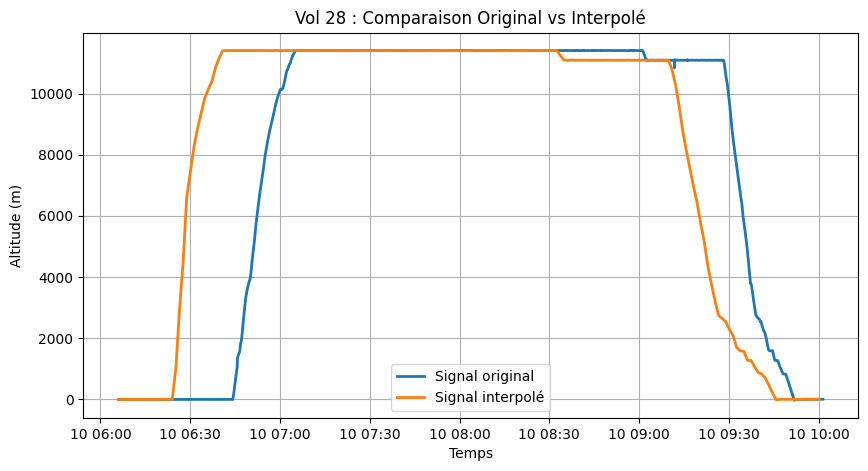

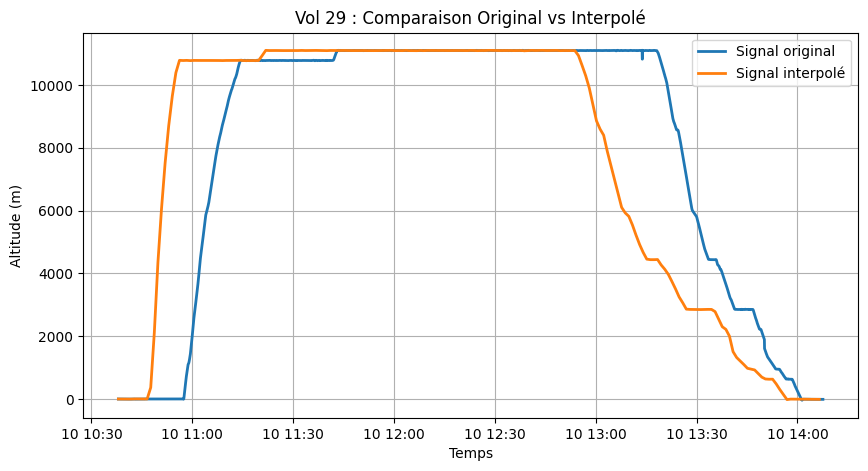

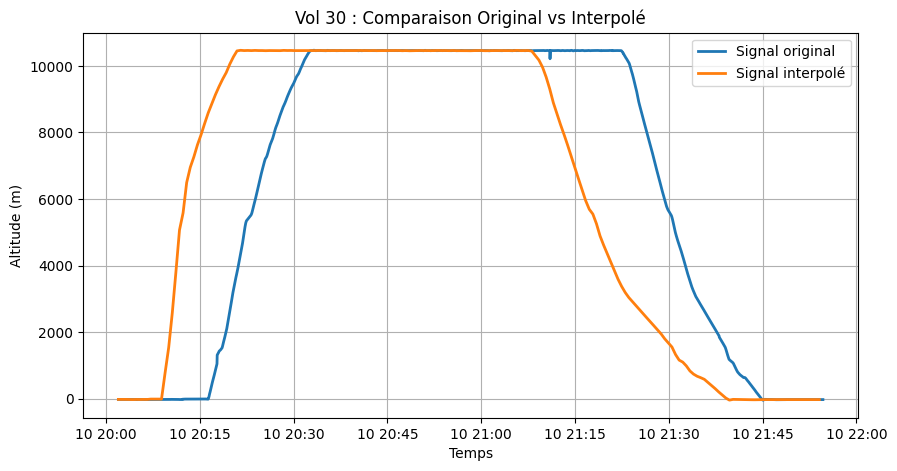

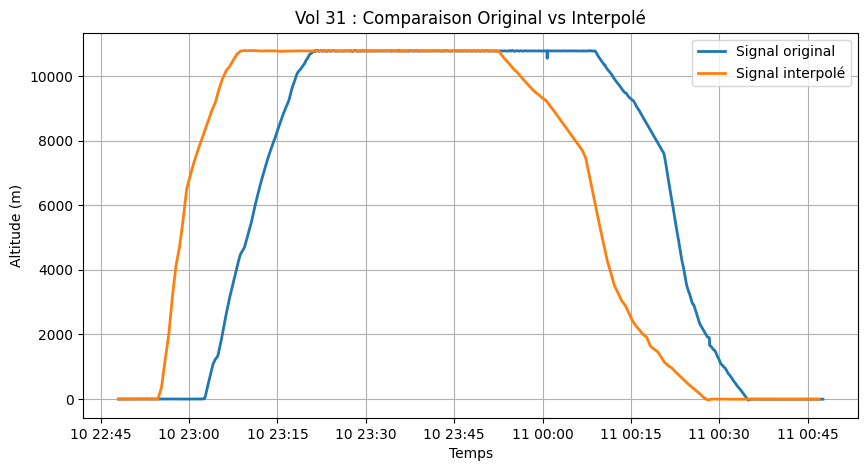

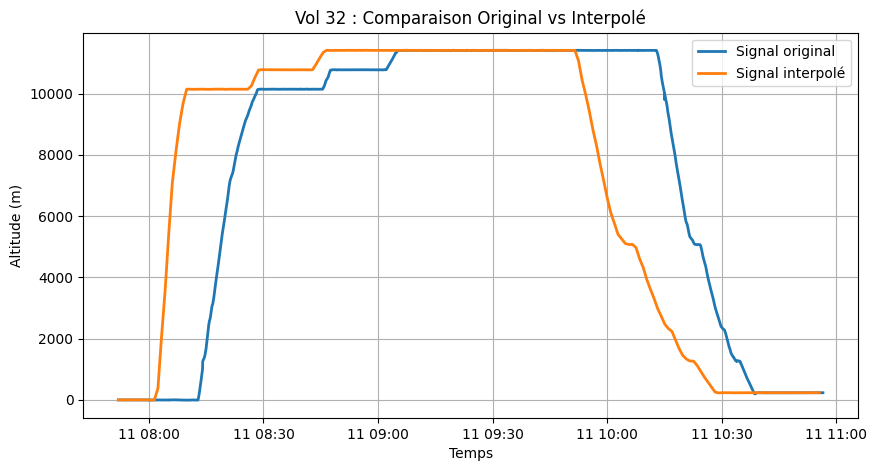

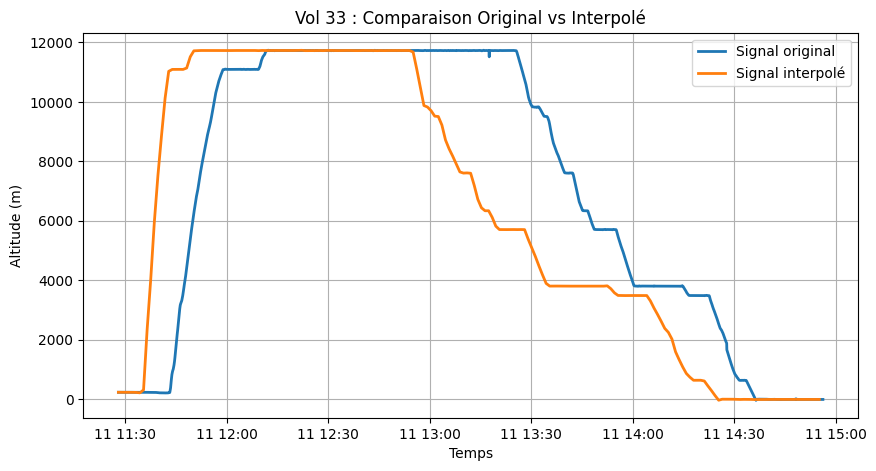

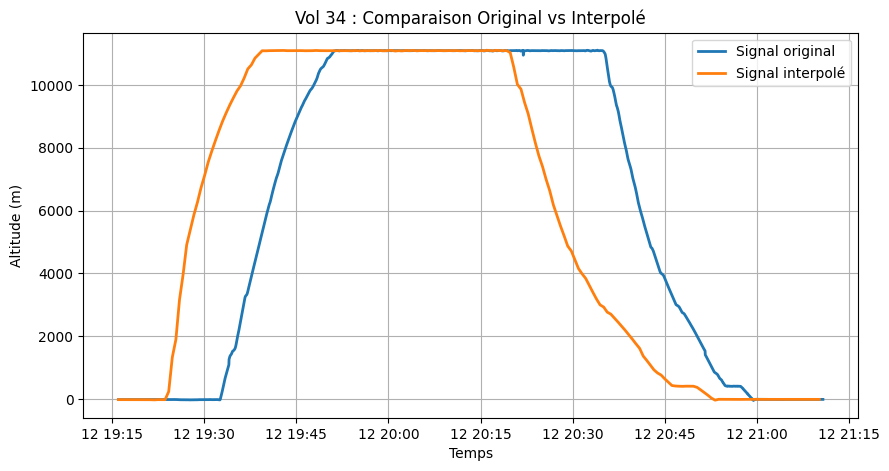

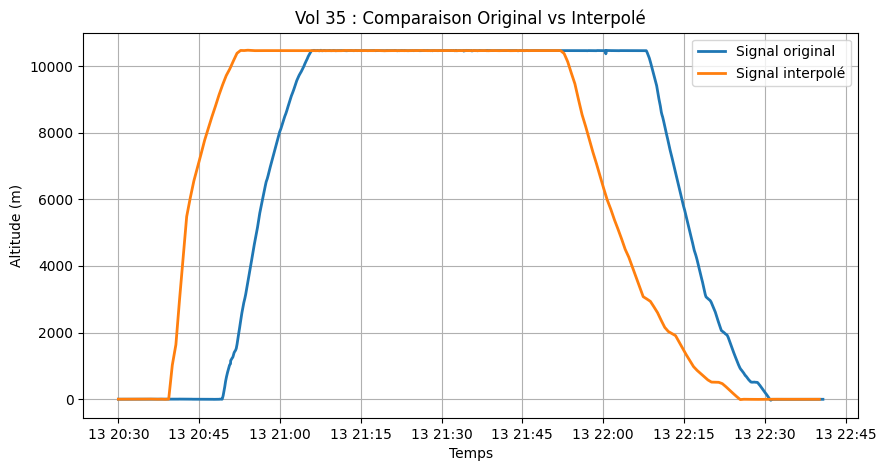

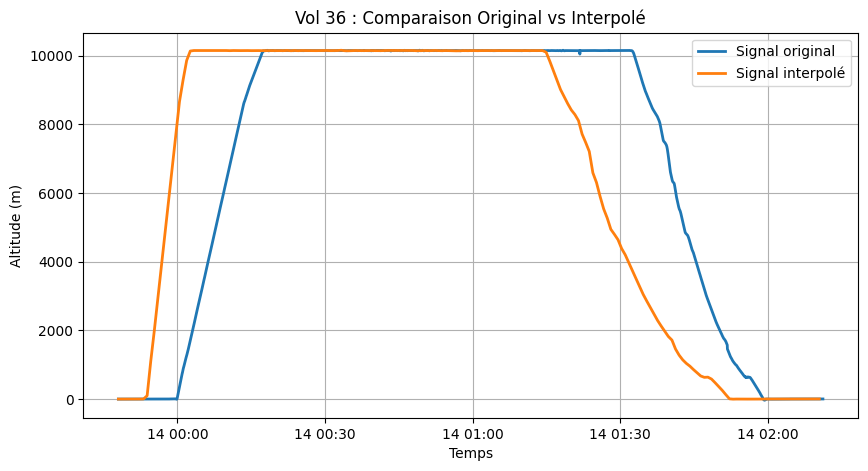

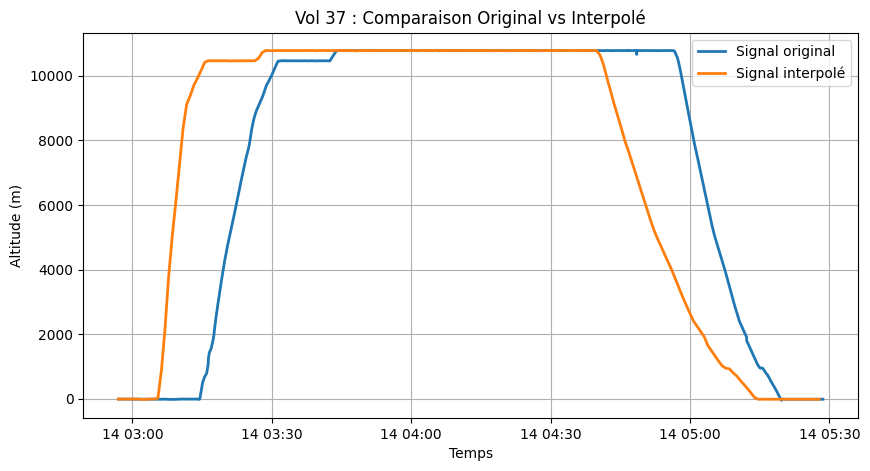

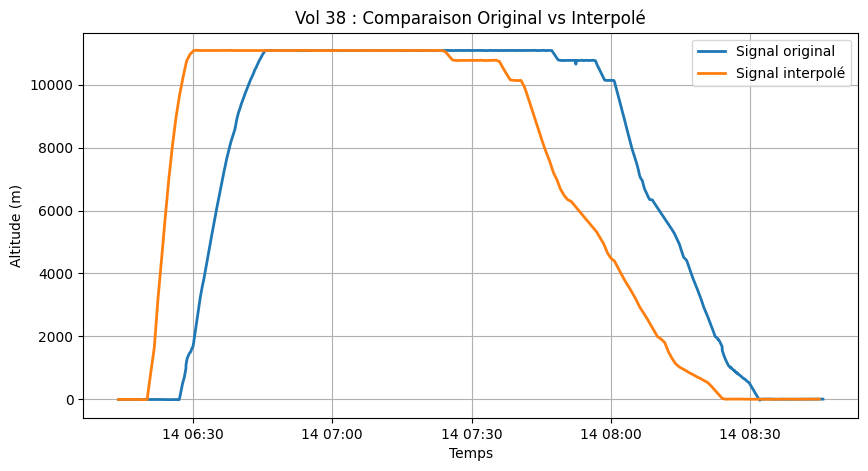

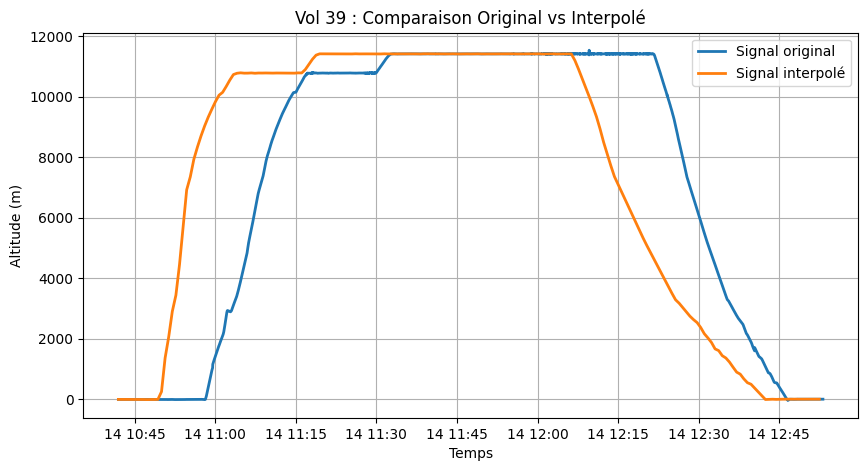

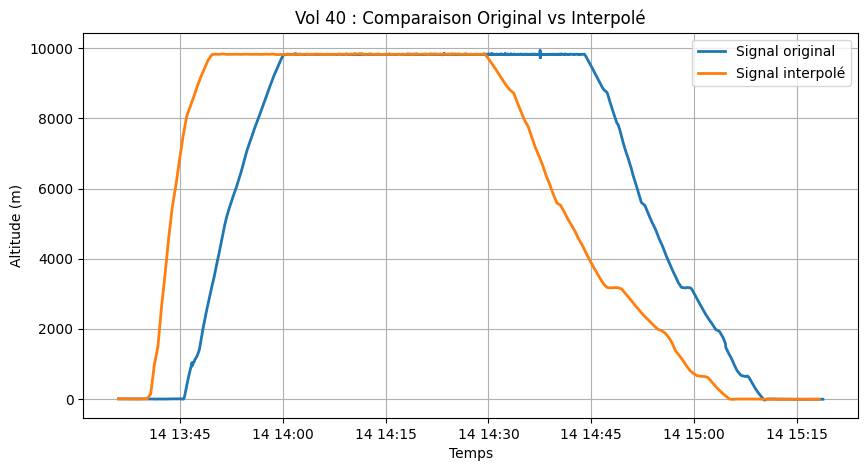

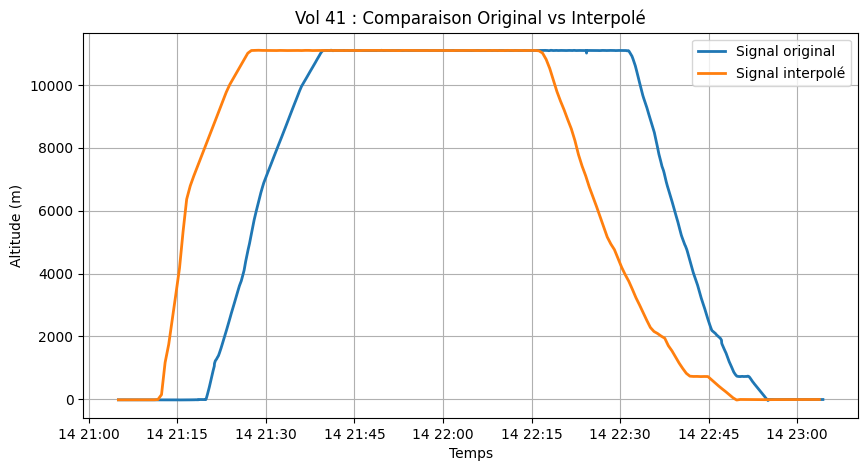

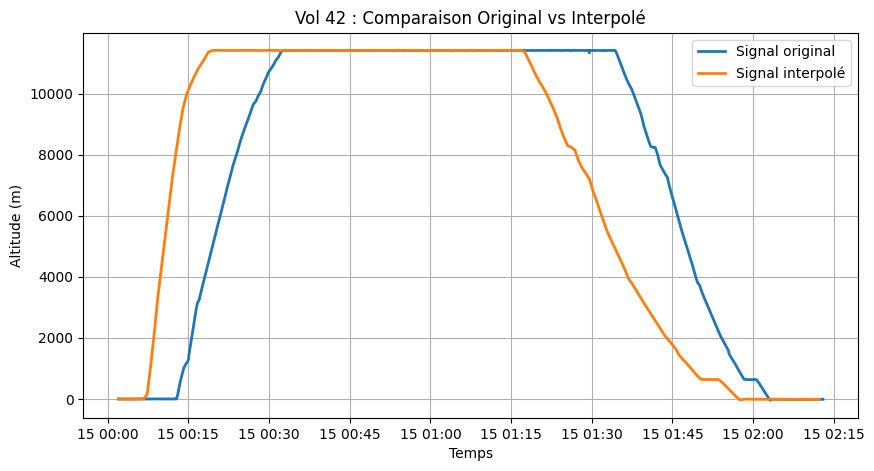

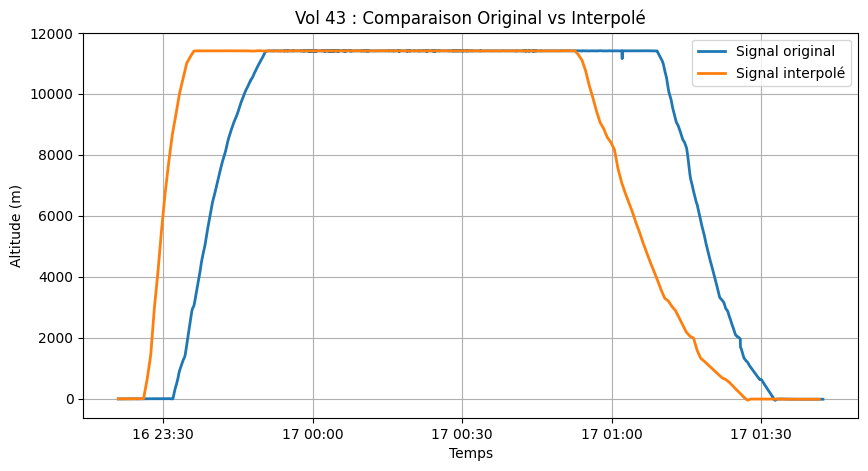

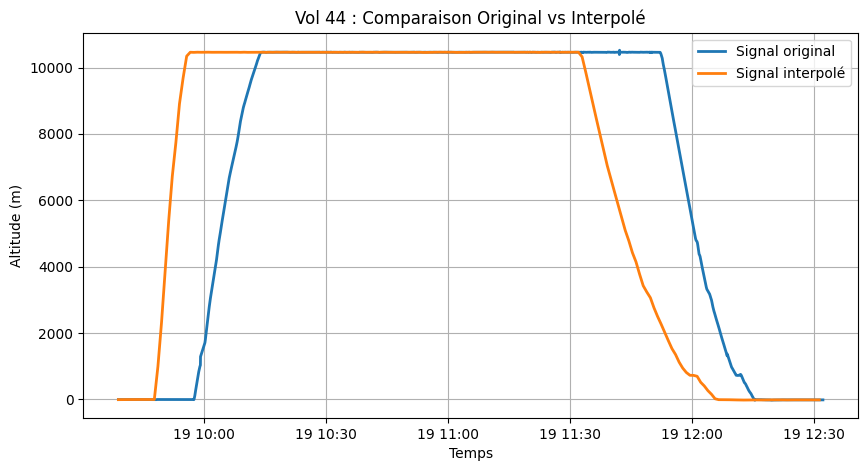

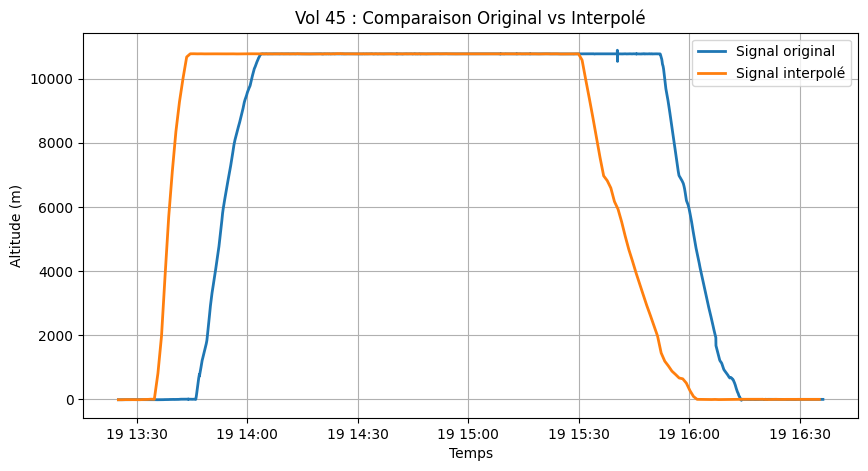

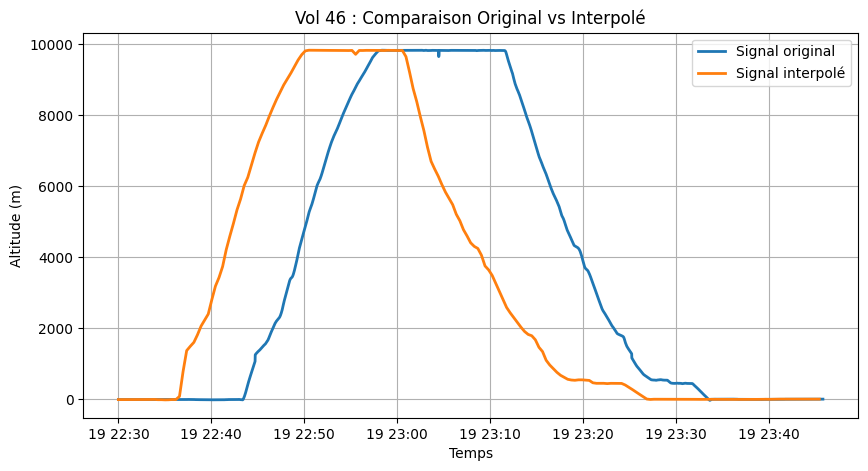

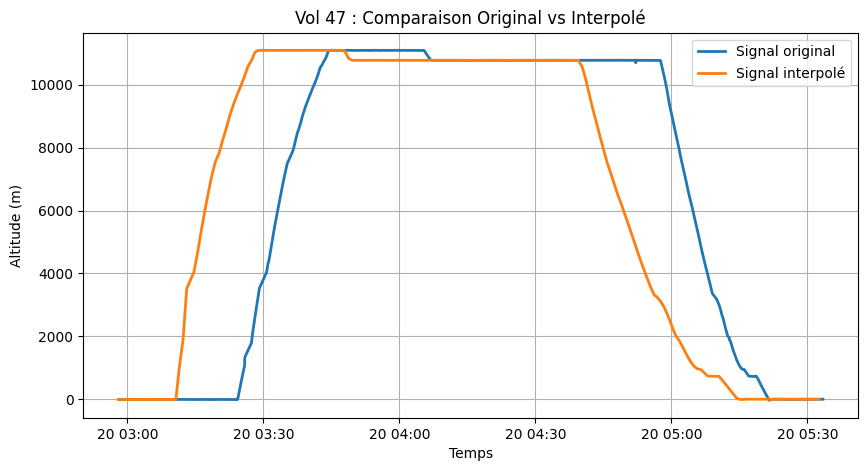

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def reechantillonner_signal(df, freq_hz=1):
    return df['ALT[m]'].resample(f'{int(1e9/freq_hz)}ns').mean().interpolate().values

def erreur_reconstruction_global(ds, R_interp, freq_hz=1):
    errors = []
    for i, df in enumerate(ds):
        y_ref = reechantillonner_signal(df, freq_hz)
        duration = df.index[-1] - df.index[0]
        interp_index = pd.date_range(start=df.index[0], periods=len(R_interp[i]),
                                     freq=f'{int(duration.total_seconds()*1e9/len(R_interp[i]))}ns')
        y_interp_rs = pd.Series(data=R_interp[i], index=interp_index).resample(f'{int(1e9/freq_hz)}ns').mean().interpolate().values
        N = min(len(y_ref), len(y_interp_rs))
        errors.append(np.sqrt(np.mean((y_ref[:N] - y_interp_rs[:N])**2)))
    return np.array(errors)



NL = [20, 40, 30, 50, 60]  # Points par phase
R = []
for df in ds:
    y = df['ALT[m]'].values
    index = df.index
    t1, t2, t3, t4 = compute_points(df)
    bounds = [0, t1, t2, t3, t4, len(df)-1]
    yn = (y - np.min(y)) / (np.max(y) - np.min(y))  # Normalisation
    y_interp = []
    for i in range(len(bounds) - 1):
        i0, i1 = bounds[i], bounds[i+1]
        t0, t1_ = index[i0].value, index[i1].value
        t_new = pd.to_datetime(np.linspace(t0, t1_, NL[i]))
        y_new = np.interp(t_new.astype(np.int64), index[i0:i1].astype(np.int64), yn[i0:i1])
        y_interp.extend(y_new if i == 0 else y_new[1:])
    R.append(y_interp)

R = pd.DataFrame(data=np.vstack(R).T)
R_interp = [R.iloc[:, i].values for i in range(R.shape[1])]

errors = erreur_reconstruction_global(ds, R_interp, freq_hz=1)

print("Erreurs de reconstruction par vol :")
for i, e in enumerate(errors):
    print(f"Vol {i+1}: erreur = {e:.4f}")
mean_error = np.nanmean(errors)
std_error = np.nanstd(errors)
print(f"\nErreur moyenne : {mean_error:.4f}, Écart-type : {std_error:.4f}")


for idx, df_ex in enumerate(ds):
    y_original = df_ex['ALT[m]']
    t_original = df_ex.index

    duration = t_original[-1] - t_original[0]
    interp_index = pd.date_range(start=t_original[0], periods=len(R_interp[idx]),
                                 freq=f'{int(duration.total_seconds()*1e9/len(R_interp[idx]))}ns')
    y_interp = R_interp[idx] * (y_original.max() - y_original.min()) + y_original.min()

    plt.figure(figsize=(10,5))
    plt.plot(t_original, y_original, label='Signal original', lw=2)
    plt.plot(interp_index, y_interp, label='Signal interpolé', lw=2)
    plt.xlabel('Temps')
    plt.ylabel('Altitude (m)')
    plt.title(f'Vol {idx+1} : Comparaison Original vs Interpolé')
    plt.legend()
    plt.grid(True)
    plt.show()


Erreurs de reconstruction par vol :
Vol 1: erreur = 8178.2050
Vol 2: erreur = 8114.2187
Vol 3: erreur = 8279.1399
Vol 4: erreur = 7866.6918
Vol 5: erreur = 4772.2334
Vol 6: erreur = 4952.1210
Vol 7: erreur = 8074.0339
Vol 8: erreur = 7478.9143
Vol 9: erreur = 7595.1914
Vol 10: erreur = 8304.3748
Vol 11: erreur = 8064.3534
Vol 12: erreur = 8105.5835
Vol 13: erreur = 7155.2023
Vol 14: erreur = 7593.0092
Vol 15: erreur = 8267.7172
Vol 16: erreur = 7565.4596
Vol 17: erreur = 6941.6158
Vol 18: erreur = 8260.1360
Vol 19: erreur = 8551.8601
Vol 20: erreur = 8972.4464
Vol 21: erreur = 7668.4374
Vol 22: erreur = 8061.8393
Vol 23: erreur = 8071.4979
Vol 24: erreur = 6230.9519
Vol 25: erreur = 7603.7410
Vol 26: erreur = 5270.5642
Vol 27: erreur = 5691.1935
Vol 28: erreur = 9306.9636
Vol 29: erreur = 9049.3190
Vol 30: erreur = 7809.5169
Vol 31: erreur = 7996.5005
Vol 32: erreur = 8849.3465
Vol 33: erreur = 8503.8651
Vol 34: erreur = 7824.2957
Vol 35: erreur = 7916.0647
Vol 36: erreur = 8023.0822
V

C:\Users\master\AppData\Local\Temp\ipykernel_5128\4013335284.py:68: FutureWarning:

'S' is deprecated and will be removed in a future version, please use 's' instead.



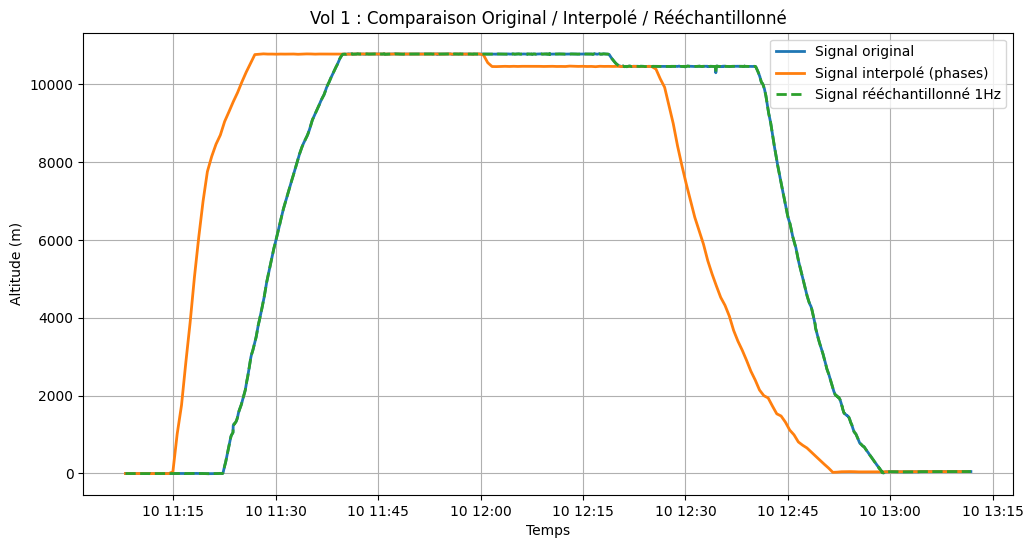

C:\Users\master\AppData\Local\Temp\ipykernel_5128\4013335284.py:68: FutureWarning:

'S' is deprecated and will be removed in a future version, please use 's' instead.



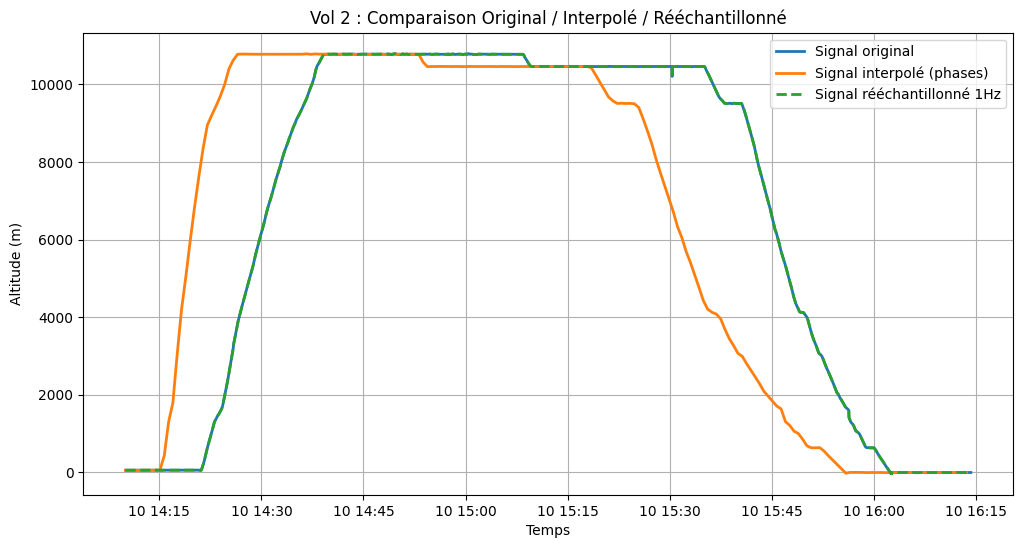

C:\Users\master\AppData\Local\Temp\ipykernel_5128\4013335284.py:68: FutureWarning:

'S' is deprecated and will be removed in a future version, please use 's' instead.



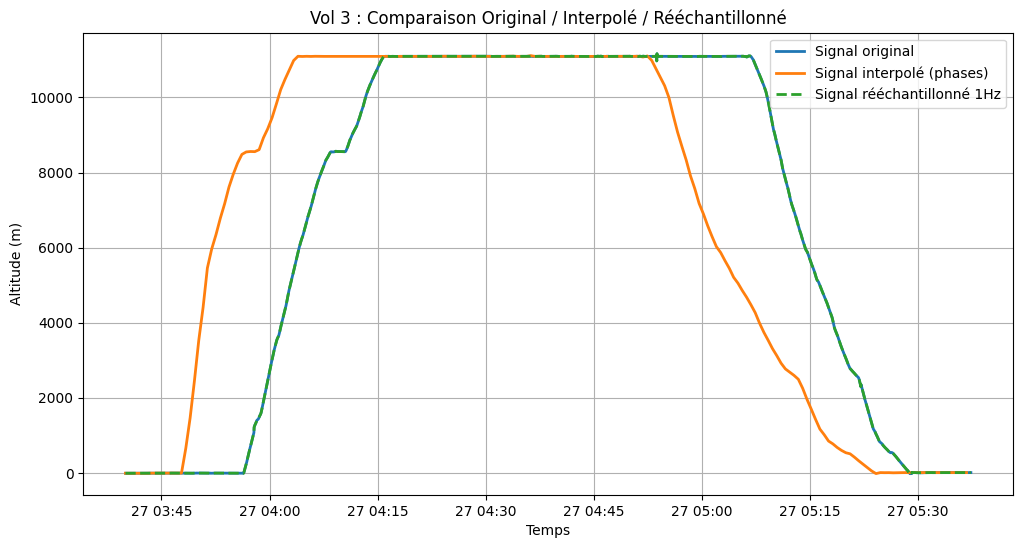

C:\Users\master\AppData\Local\Temp\ipykernel_5128\4013335284.py:68: FutureWarning:

'S' is deprecated and will be removed in a future version, please use 's' instead.



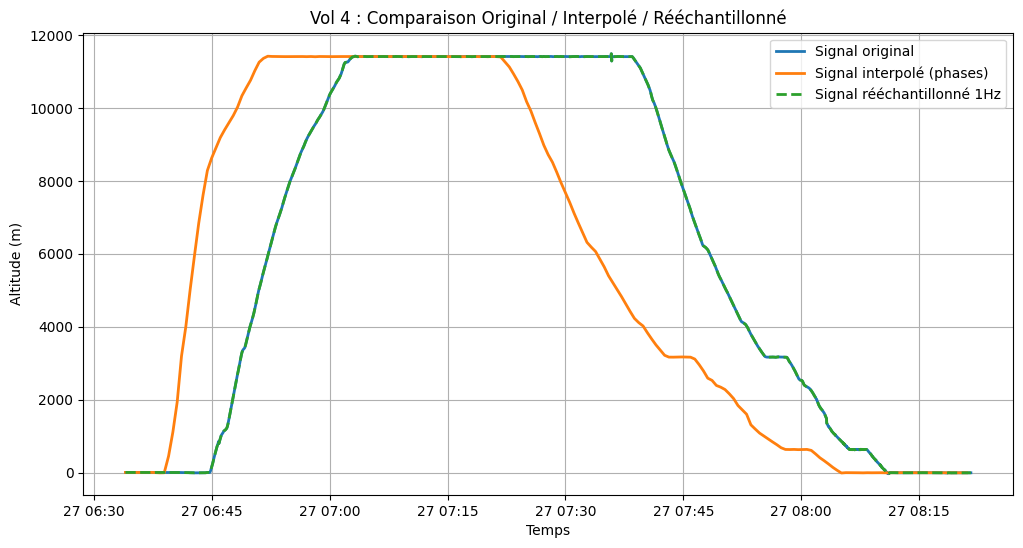

C:\Users\master\AppData\Local\Temp\ipykernel_5128\4013335284.py:68: FutureWarning:

'S' is deprecated and will be removed in a future version, please use 's' instead.



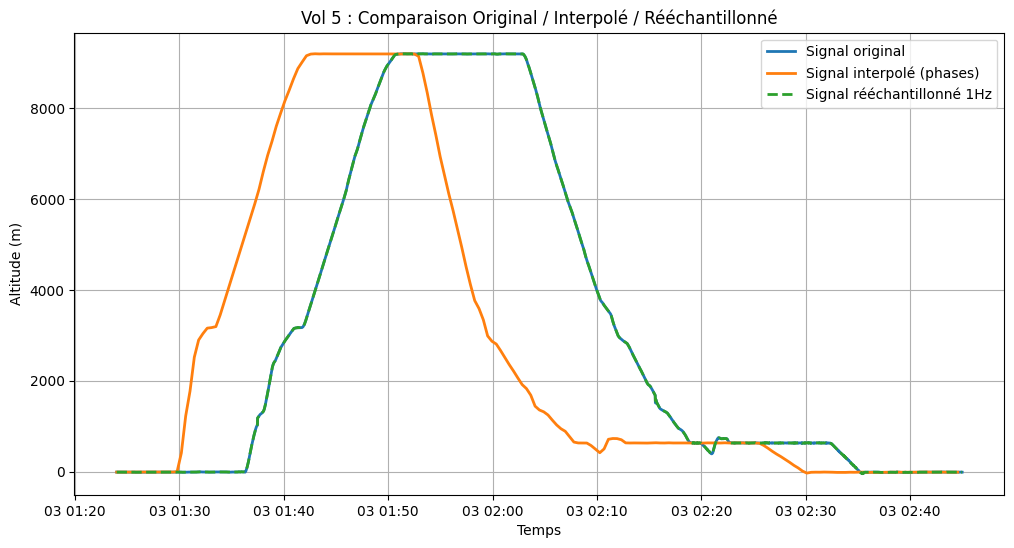

C:\Users\master\AppData\Local\Temp\ipykernel_5128\4013335284.py:68: FutureWarning:

'S' is deprecated and will be removed in a future version, please use 's' instead.



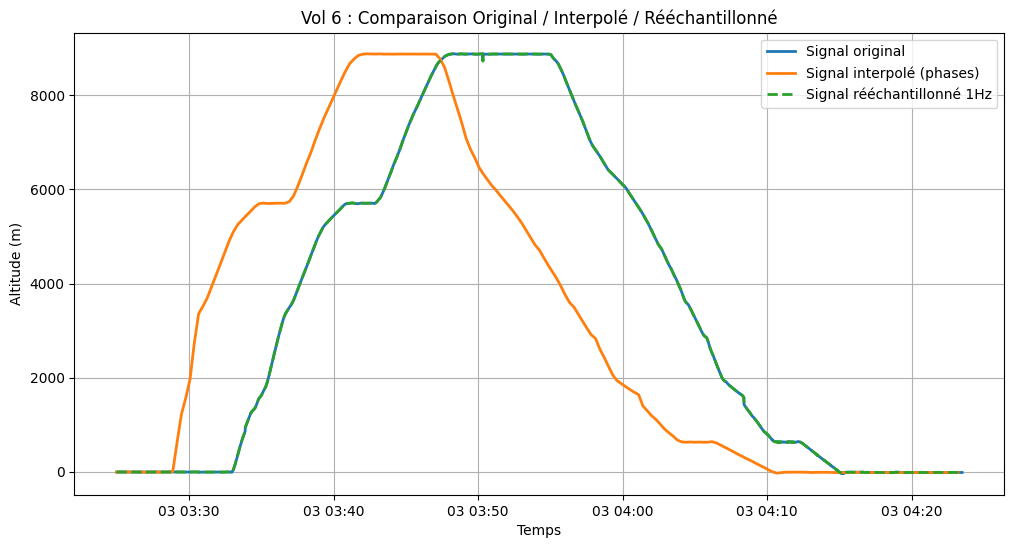

C:\Users\master\AppData\Local\Temp\ipykernel_5128\4013335284.py:68: FutureWarning:

'S' is deprecated and will be removed in a future version, please use 's' instead.



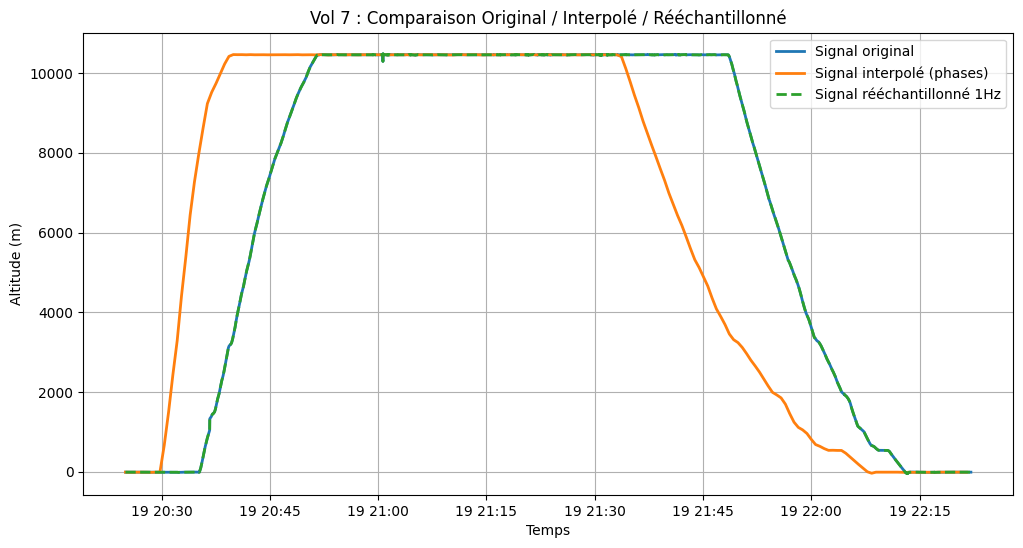

C:\Users\master\AppData\Local\Temp\ipykernel_5128\4013335284.py:68: FutureWarning:

'S' is deprecated and will be removed in a future version, please use 's' instead.



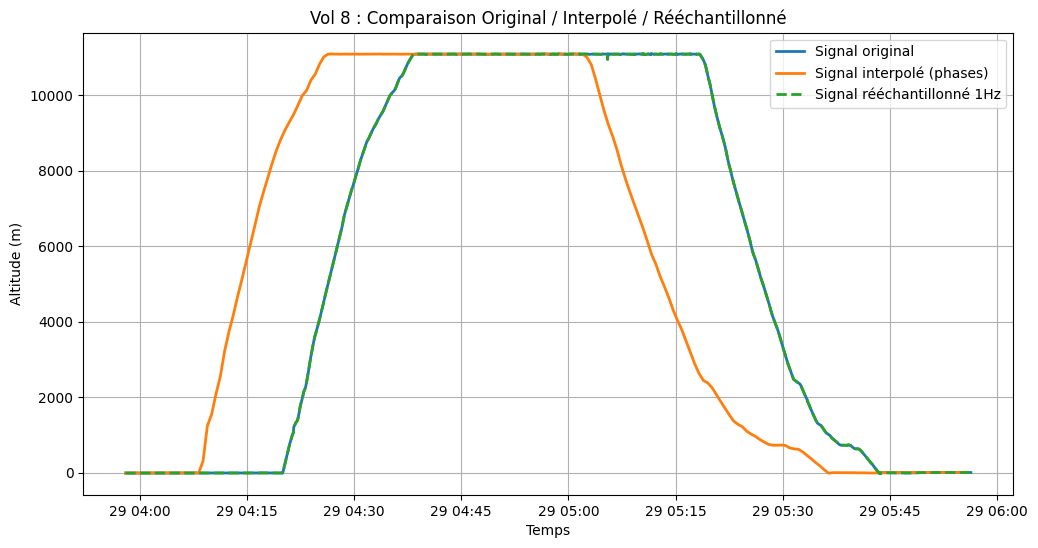

C:\Users\master\AppData\Local\Temp\ipykernel_5128\4013335284.py:68: FutureWarning:

'S' is deprecated and will be removed in a future version, please use 's' instead.



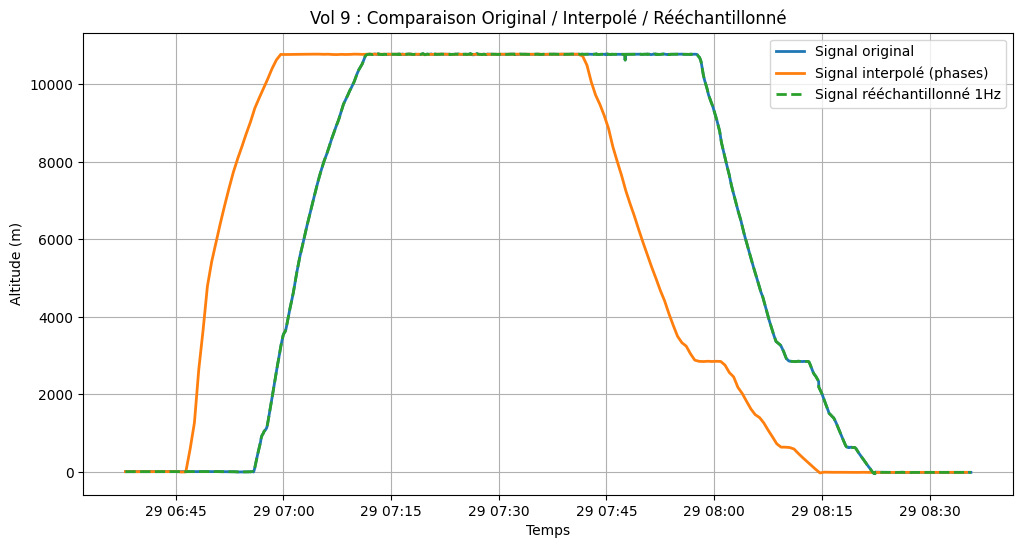

C:\Users\master\AppData\Local\Temp\ipykernel_5128\4013335284.py:68: FutureWarning:

'S' is deprecated and will be removed in a future version, please use 's' instead.



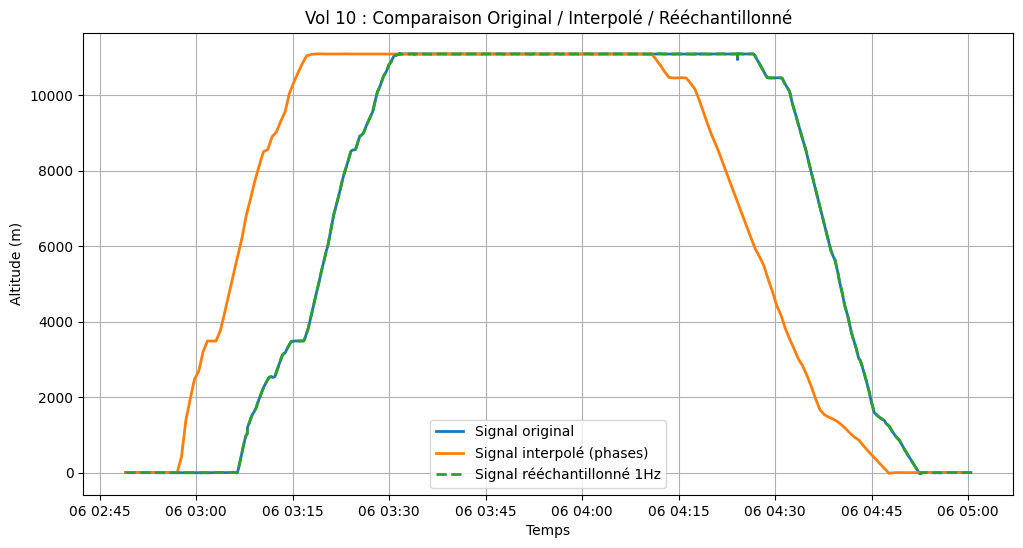

C:\Users\master\AppData\Local\Temp\ipykernel_5128\4013335284.py:68: FutureWarning:

'S' is deprecated and will be removed in a future version, please use 's' instead.



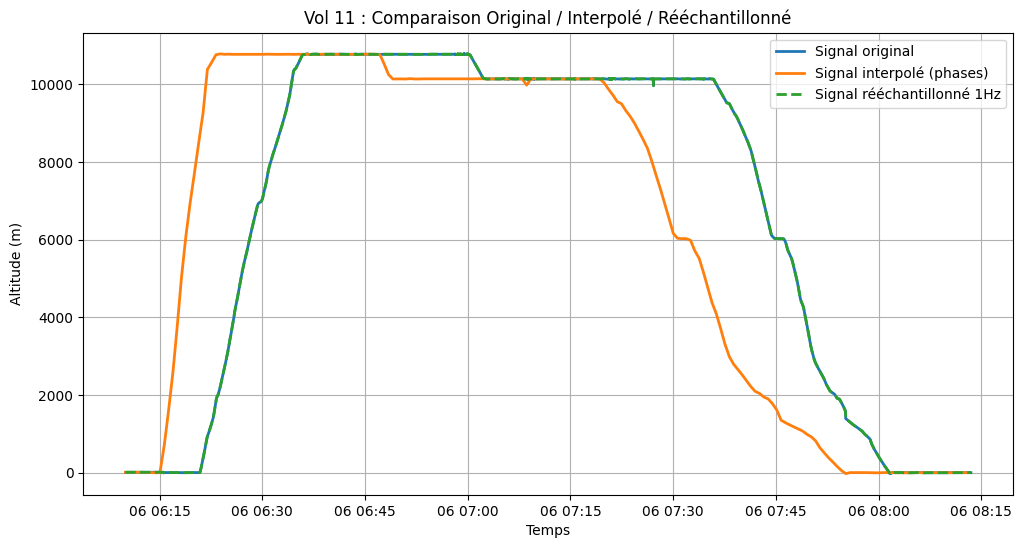

C:\Users\master\AppData\Local\Temp\ipykernel_5128\4013335284.py:68: FutureWarning:

'S' is deprecated and will be removed in a future version, please use 's' instead.



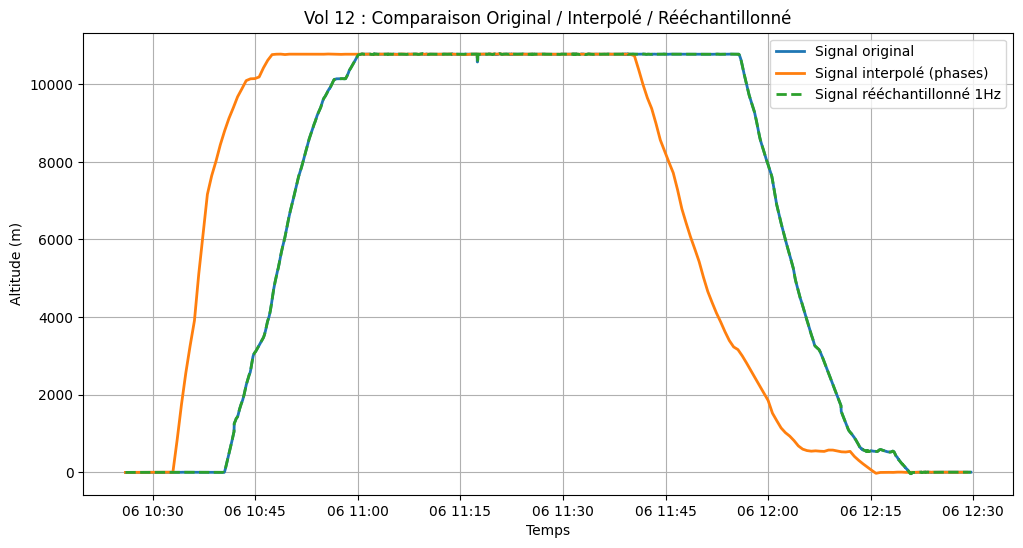

C:\Users\master\AppData\Local\Temp\ipykernel_5128\4013335284.py:68: FutureWarning:

'S' is deprecated and will be removed in a future version, please use 's' instead.



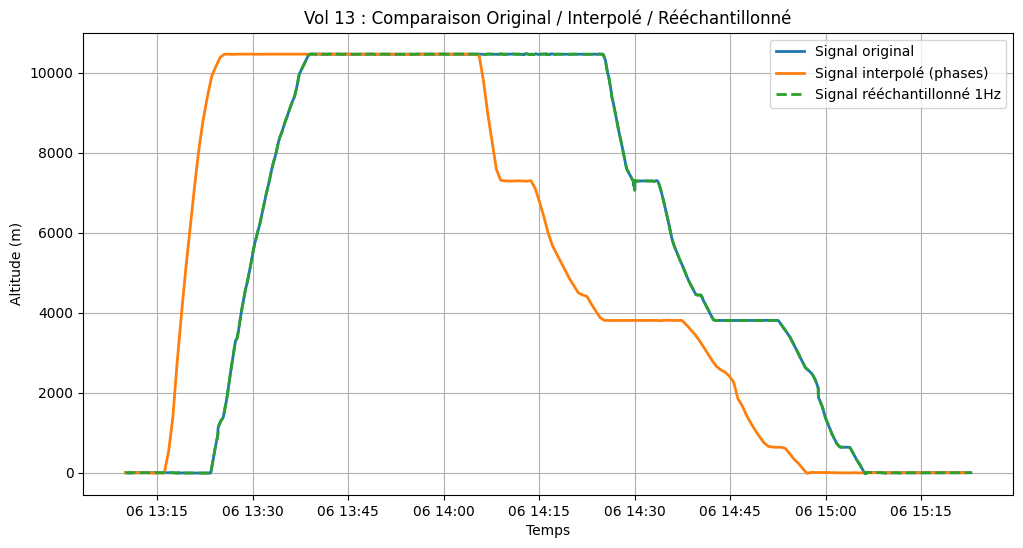

C:\Users\master\AppData\Local\Temp\ipykernel_5128\4013335284.py:68: FutureWarning:

'S' is deprecated and will be removed in a future version, please use 's' instead.



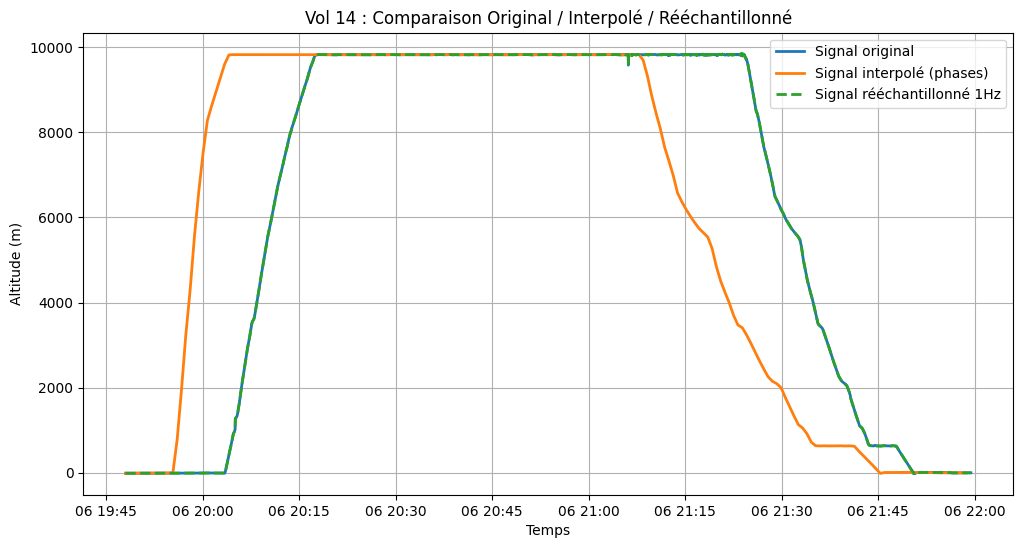

C:\Users\master\AppData\Local\Temp\ipykernel_5128\4013335284.py:68: FutureWarning:

'S' is deprecated and will be removed in a future version, please use 's' instead.



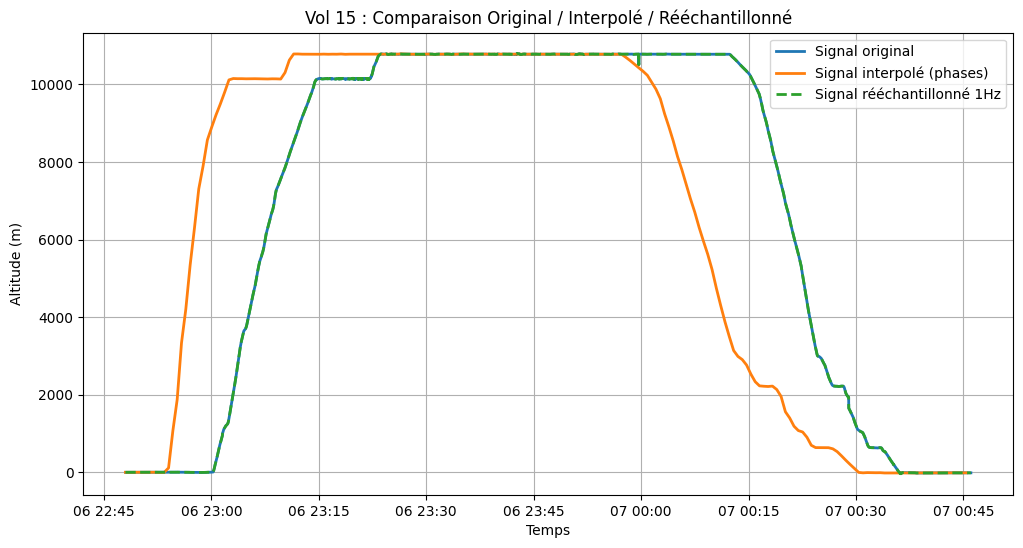

C:\Users\master\AppData\Local\Temp\ipykernel_5128\4013335284.py:68: FutureWarning:

'S' is deprecated and will be removed in a future version, please use 's' instead.



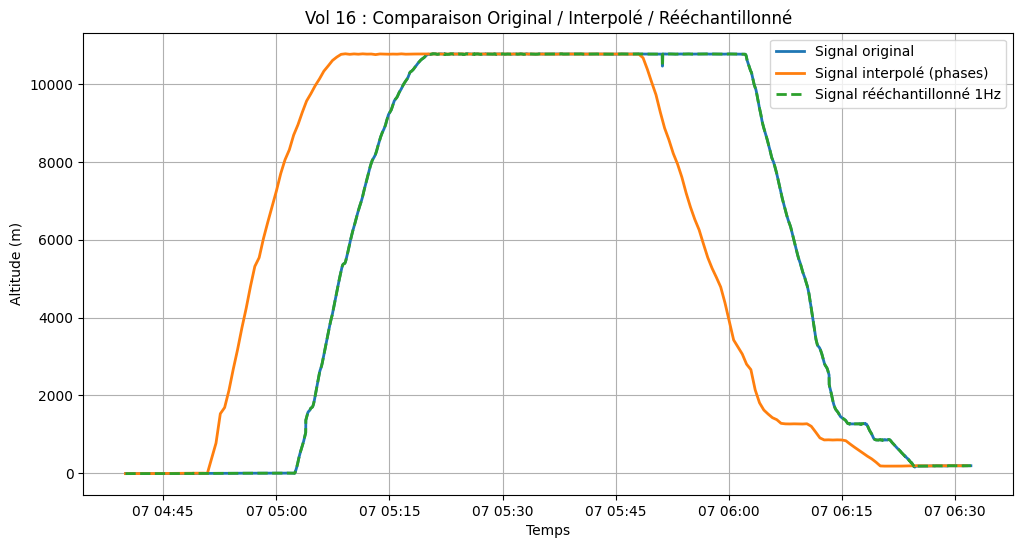

C:\Users\master\AppData\Local\Temp\ipykernel_5128\4013335284.py:68: FutureWarning:

'S' is deprecated and will be removed in a future version, please use 's' instead.



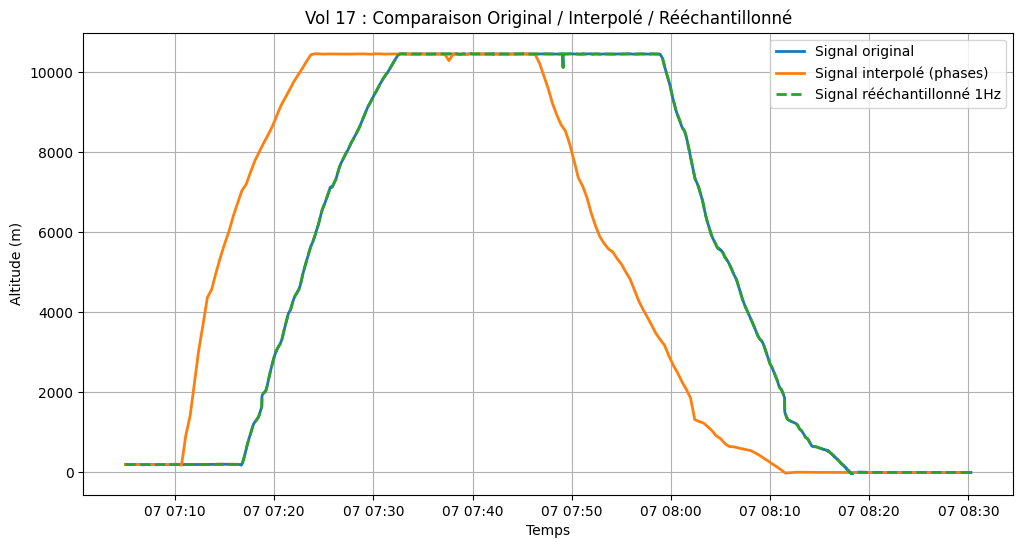

C:\Users\master\AppData\Local\Temp\ipykernel_5128\4013335284.py:68: FutureWarning:

'S' is deprecated and will be removed in a future version, please use 's' instead.



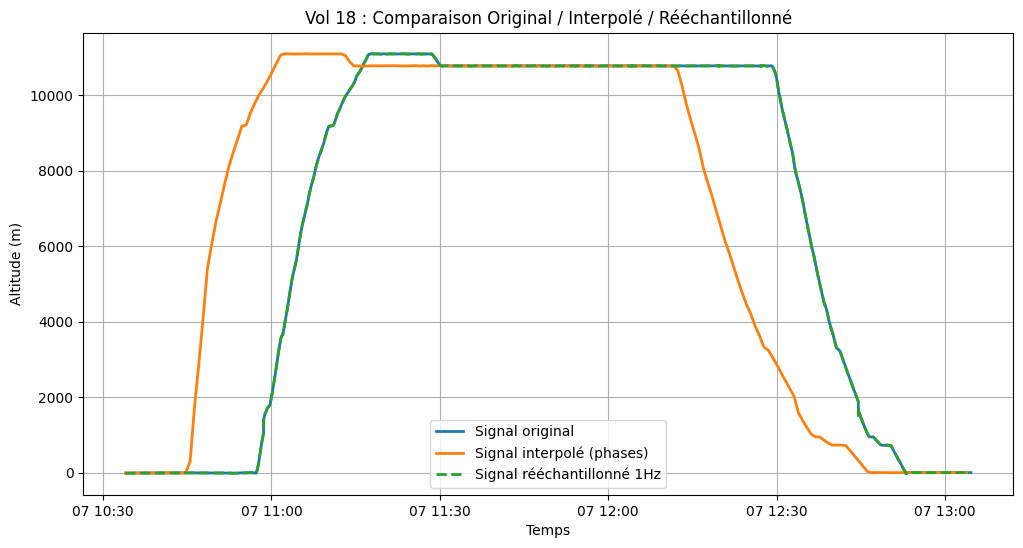

C:\Users\master\AppData\Local\Temp\ipykernel_5128\4013335284.py:68: FutureWarning:

'S' is deprecated and will be removed in a future version, please use 's' instead.



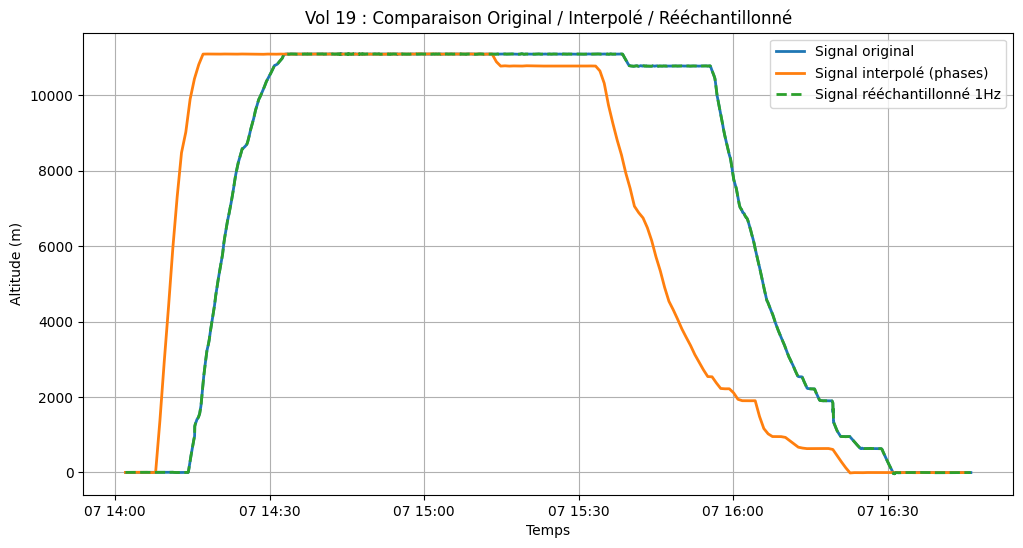

C:\Users\master\AppData\Local\Temp\ipykernel_5128\4013335284.py:68: FutureWarning:

'S' is deprecated and will be removed in a future version, please use 's' instead.



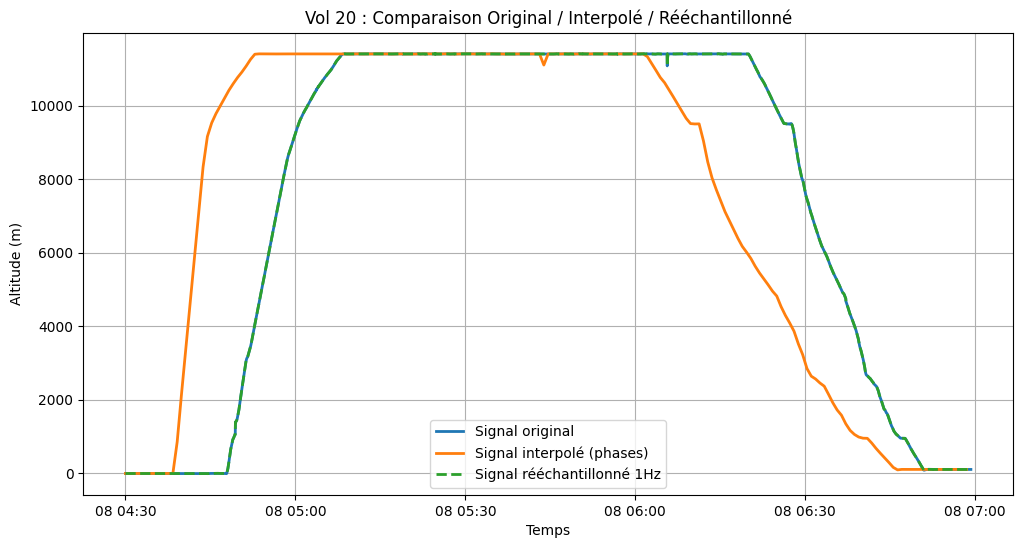

C:\Users\master\AppData\Local\Temp\ipykernel_5128\4013335284.py:68: FutureWarning:

'S' is deprecated and will be removed in a future version, please use 's' instead.



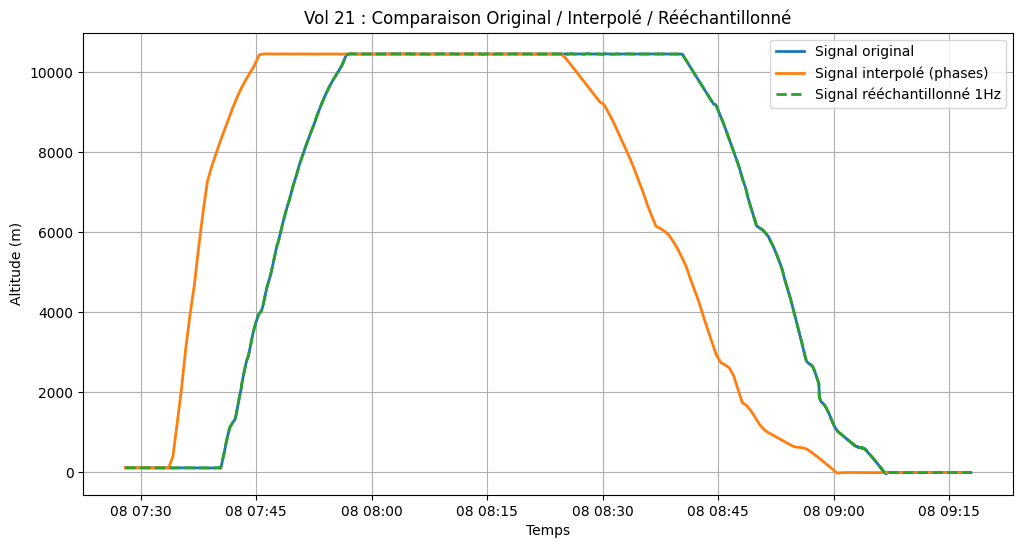

C:\Users\master\AppData\Local\Temp\ipykernel_5128\4013335284.py:68: FutureWarning:

'S' is deprecated and will be removed in a future version, please use 's' instead.



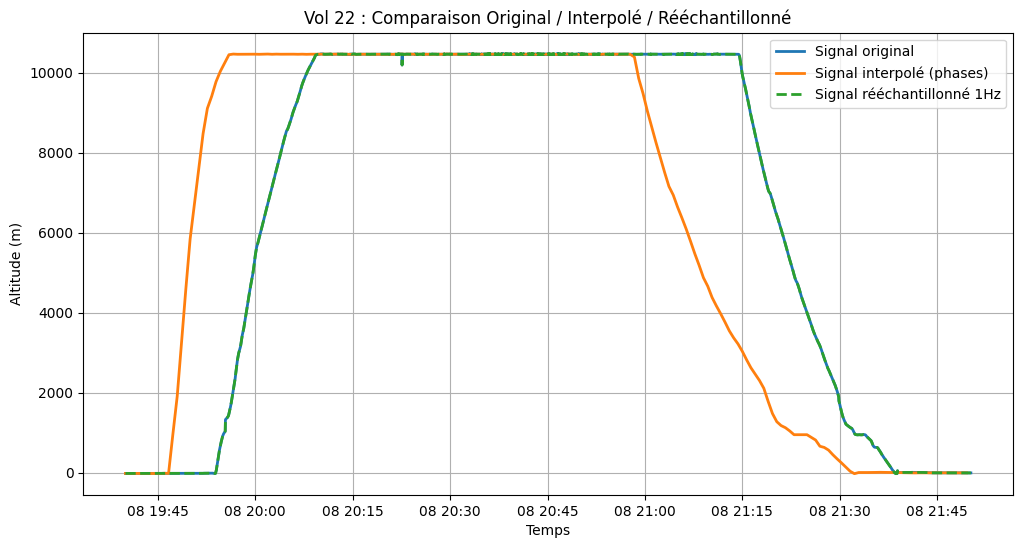

C:\Users\master\AppData\Local\Temp\ipykernel_5128\4013335284.py:68: FutureWarning:

'S' is deprecated and will be removed in a future version, please use 's' instead.



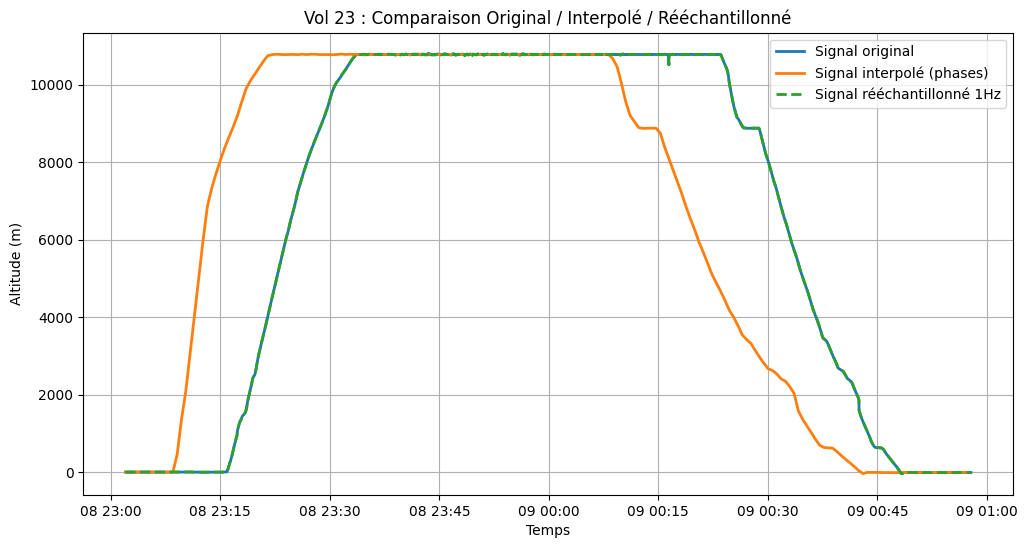

C:\Users\master\AppData\Local\Temp\ipykernel_5128\4013335284.py:68: FutureWarning:

'S' is deprecated and will be removed in a future version, please use 's' instead.



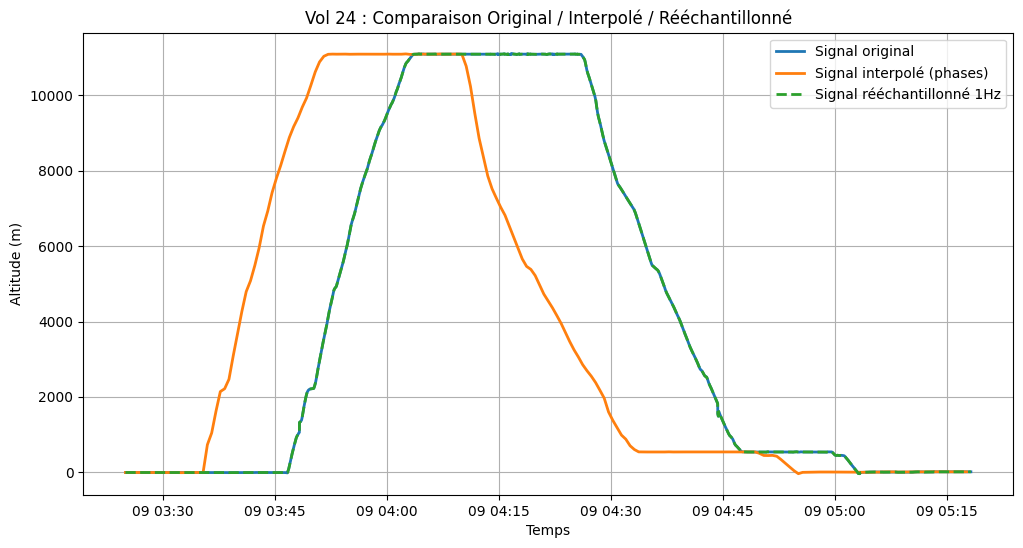

C:\Users\master\AppData\Local\Temp\ipykernel_5128\4013335284.py:68: FutureWarning:

'S' is deprecated and will be removed in a future version, please use 's' instead.



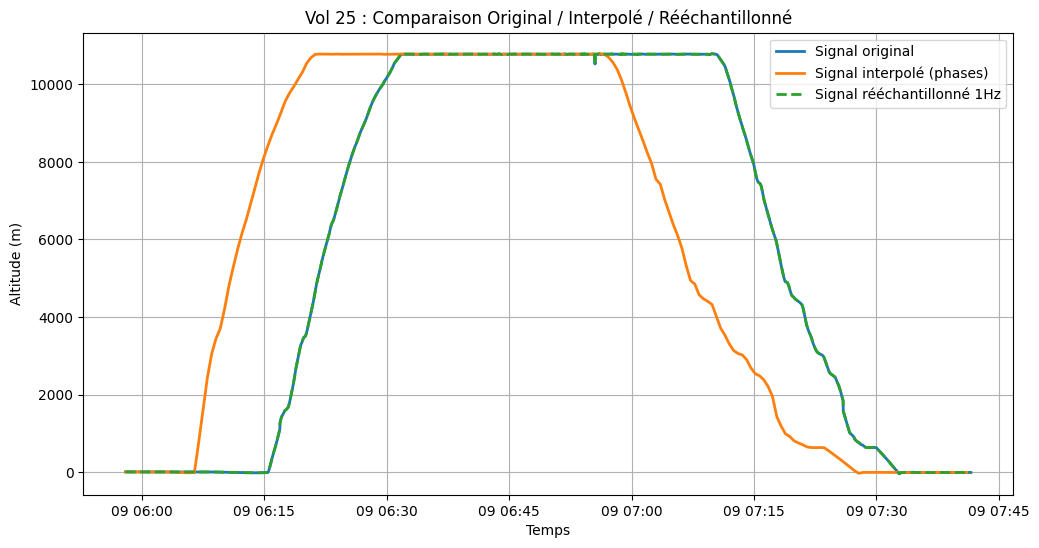

C:\Users\master\AppData\Local\Temp\ipykernel_5128\4013335284.py:68: FutureWarning:

'S' is deprecated and will be removed in a future version, please use 's' instead.



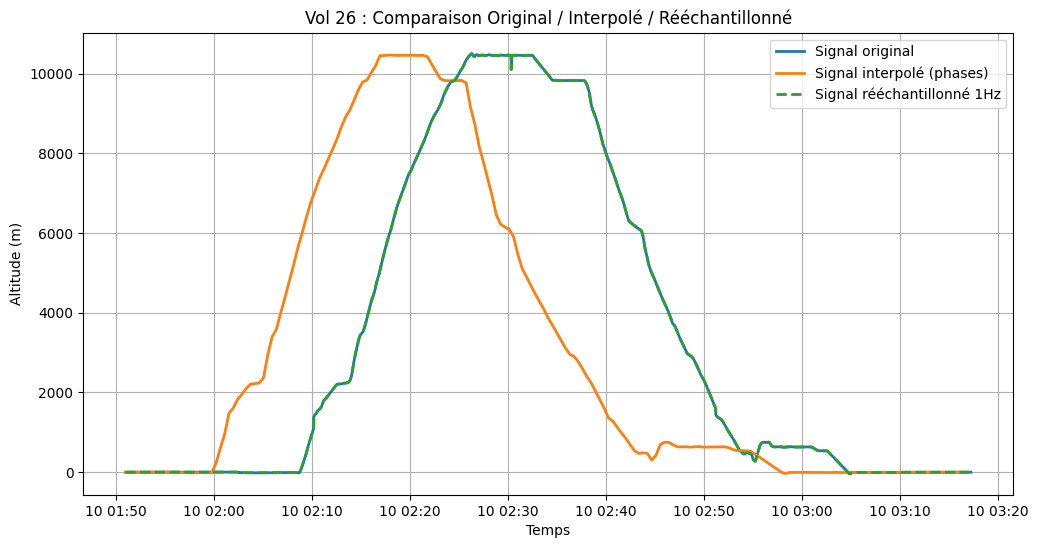

C:\Users\master\AppData\Local\Temp\ipykernel_5128\4013335284.py:68: FutureWarning:

'S' is deprecated and will be removed in a future version, please use 's' instead.



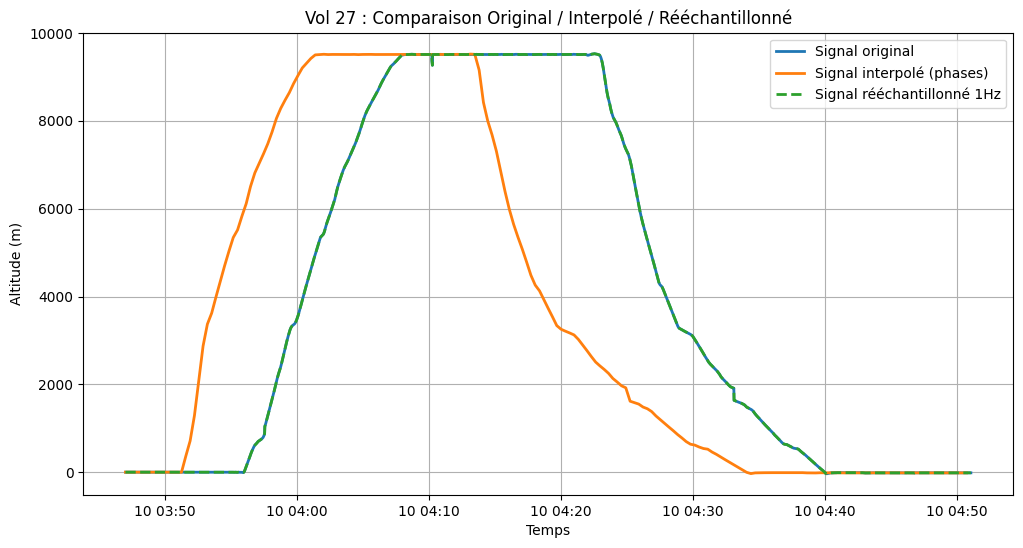

C:\Users\master\AppData\Local\Temp\ipykernel_5128\4013335284.py:68: FutureWarning:

'S' is deprecated and will be removed in a future version, please use 's' instead.



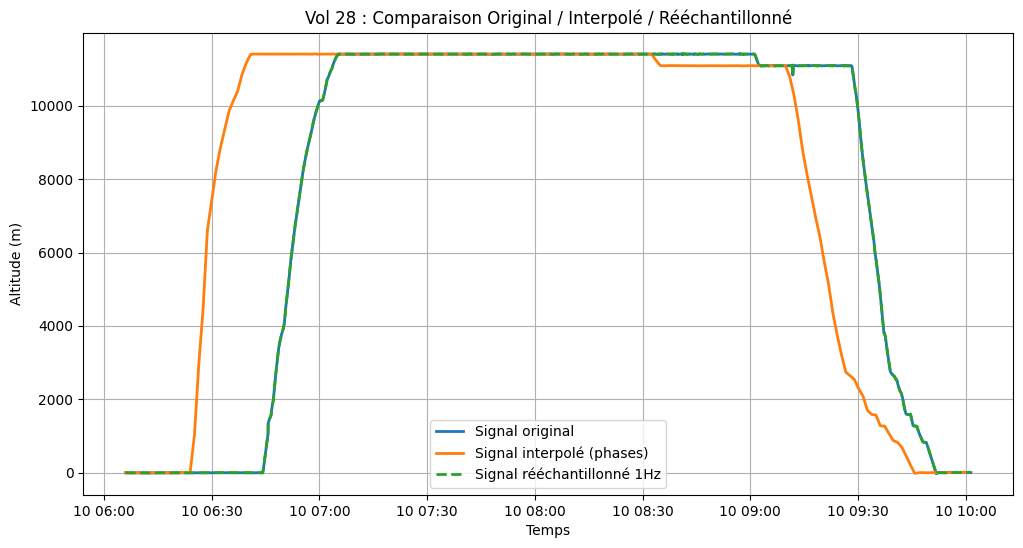

C:\Users\master\AppData\Local\Temp\ipykernel_5128\4013335284.py:68: FutureWarning:

'S' is deprecated and will be removed in a future version, please use 's' instead.



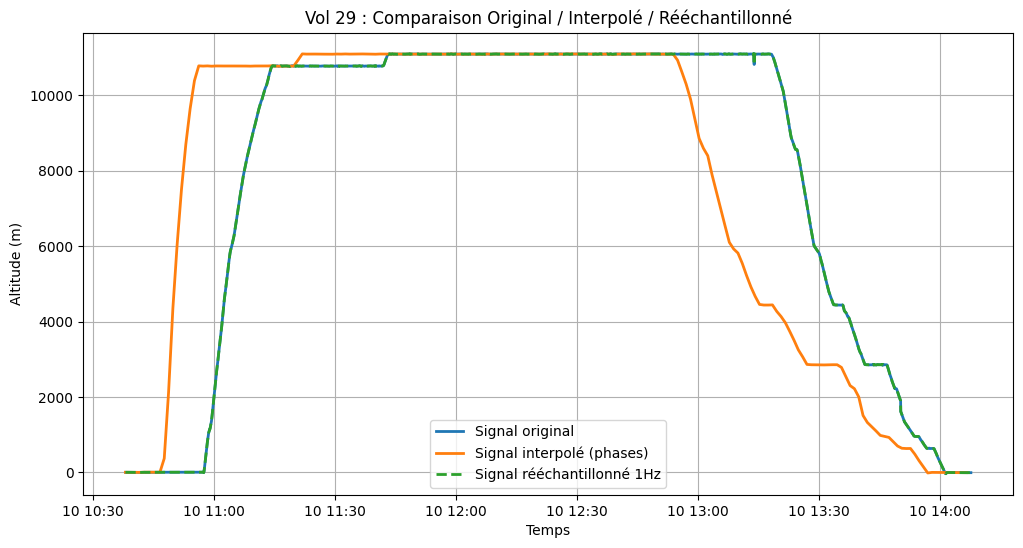

C:\Users\master\AppData\Local\Temp\ipykernel_5128\4013335284.py:68: FutureWarning:

'S' is deprecated and will be removed in a future version, please use 's' instead.



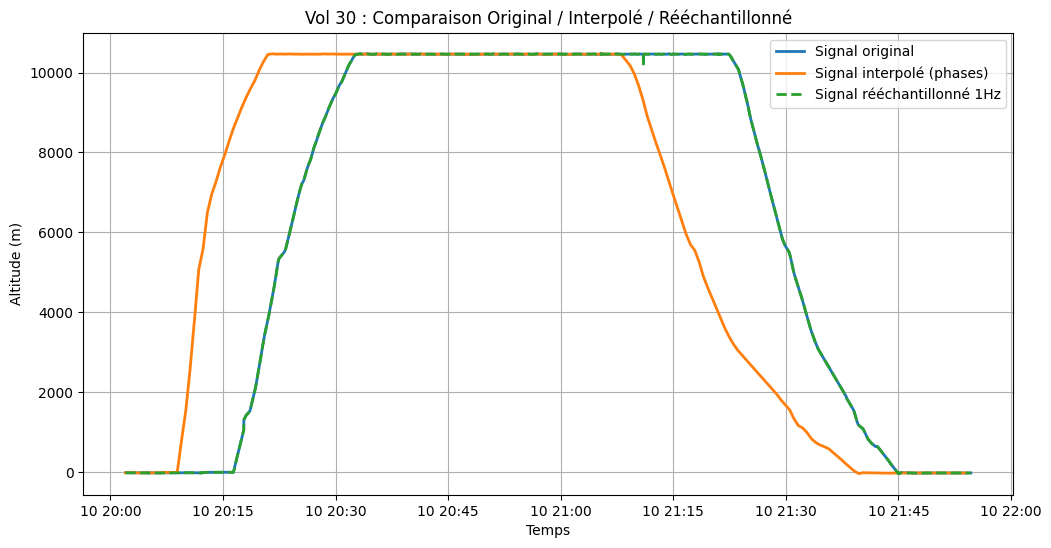

C:\Users\master\AppData\Local\Temp\ipykernel_5128\4013335284.py:68: FutureWarning:

'S' is deprecated and will be removed in a future version, please use 's' instead.



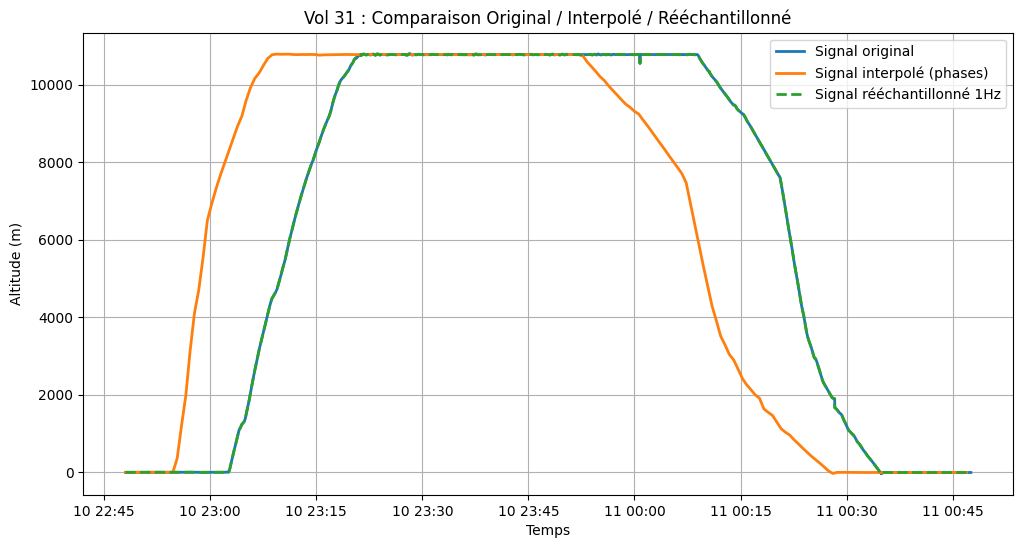

C:\Users\master\AppData\Local\Temp\ipykernel_5128\4013335284.py:68: FutureWarning:

'S' is deprecated and will be removed in a future version, please use 's' instead.



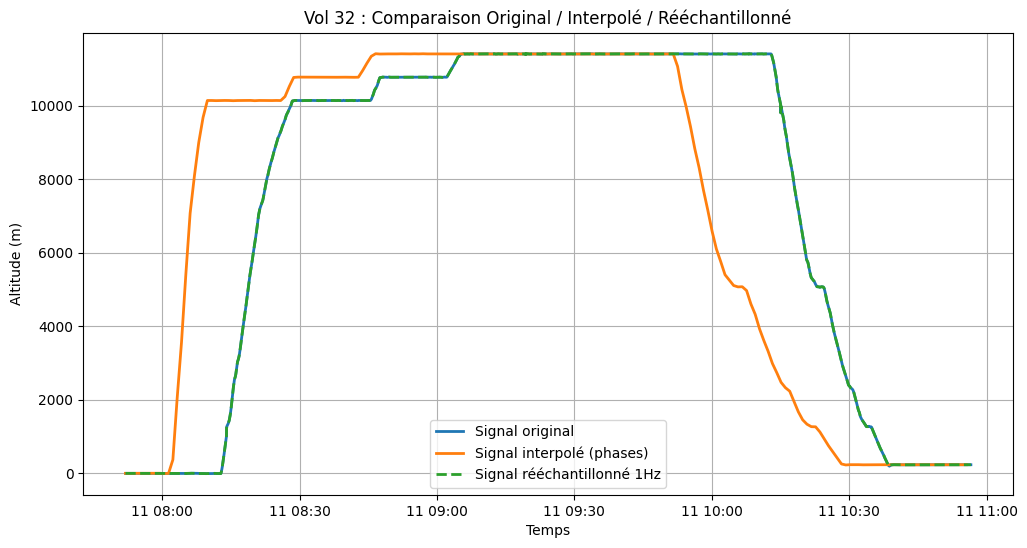

C:\Users\master\AppData\Local\Temp\ipykernel_5128\4013335284.py:68: FutureWarning:

'S' is deprecated and will be removed in a future version, please use 's' instead.



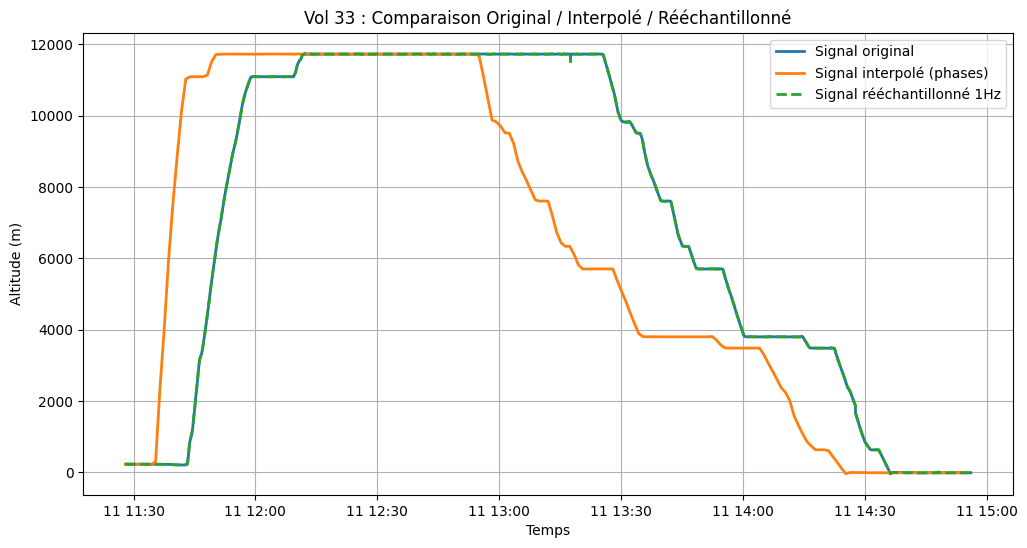

C:\Users\master\AppData\Local\Temp\ipykernel_5128\4013335284.py:68: FutureWarning:

'S' is deprecated and will be removed in a future version, please use 's' instead.



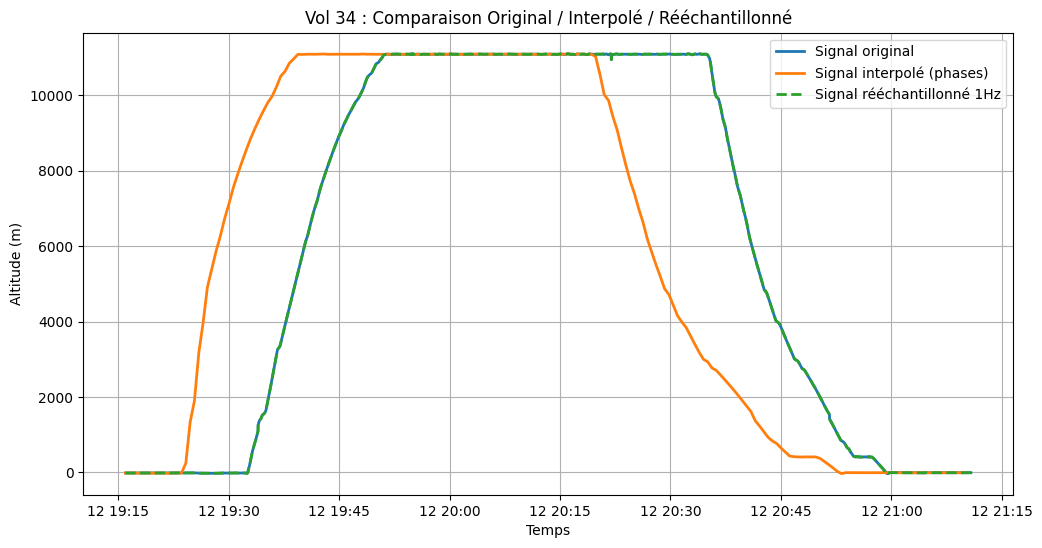

C:\Users\master\AppData\Local\Temp\ipykernel_5128\4013335284.py:68: FutureWarning:

'S' is deprecated and will be removed in a future version, please use 's' instead.



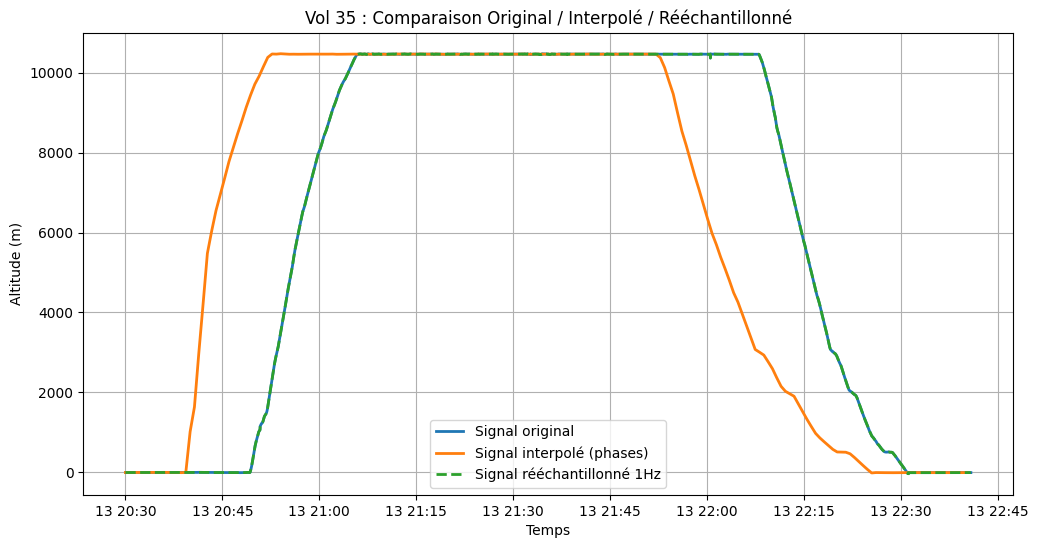

C:\Users\master\AppData\Local\Temp\ipykernel_5128\4013335284.py:68: FutureWarning:

'S' is deprecated and will be removed in a future version, please use 's' instead.



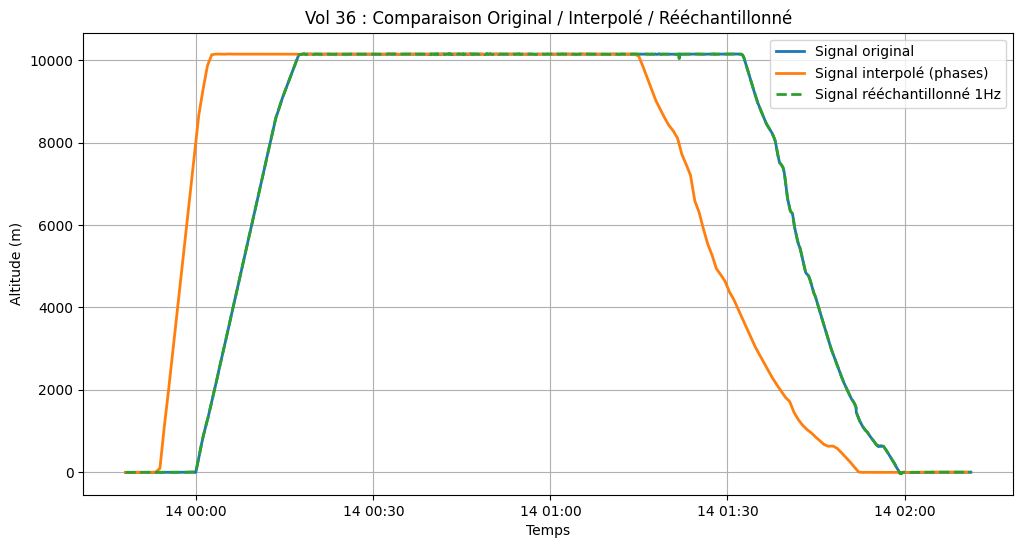

C:\Users\master\AppData\Local\Temp\ipykernel_5128\4013335284.py:68: FutureWarning:

'S' is deprecated and will be removed in a future version, please use 's' instead.



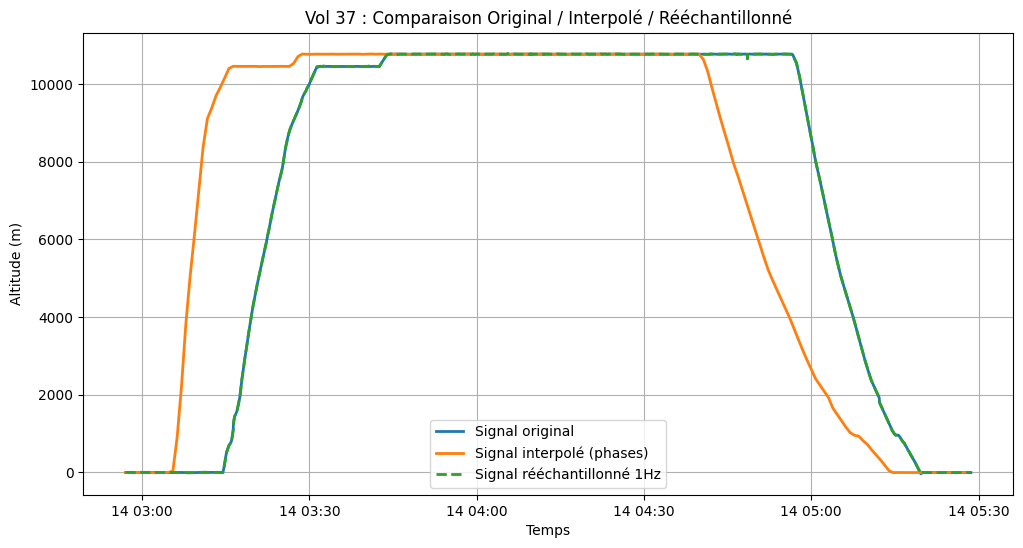

C:\Users\master\AppData\Local\Temp\ipykernel_5128\4013335284.py:68: FutureWarning:

'S' is deprecated and will be removed in a future version, please use 's' instead.



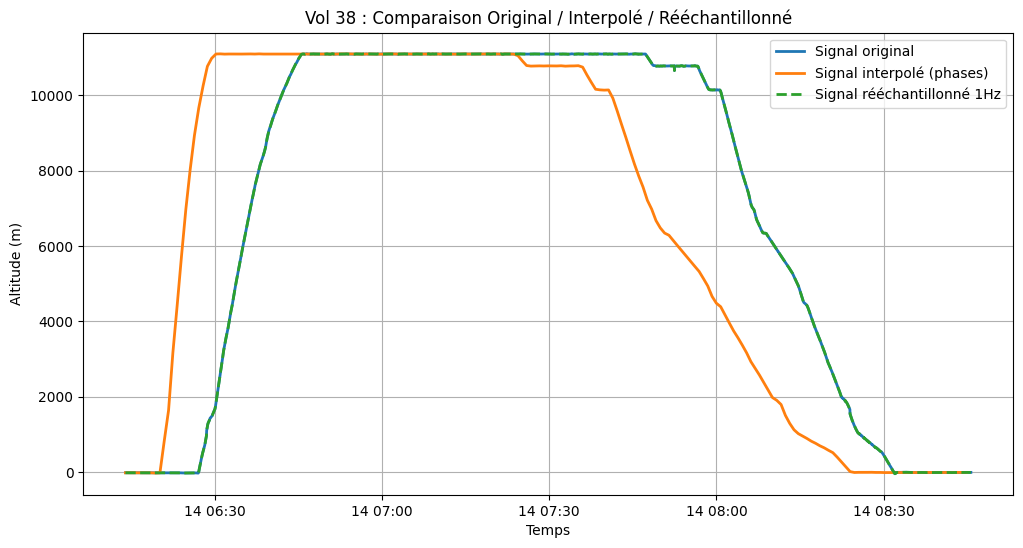

C:\Users\master\AppData\Local\Temp\ipykernel_5128\4013335284.py:68: FutureWarning:

'S' is deprecated and will be removed in a future version, please use 's' instead.



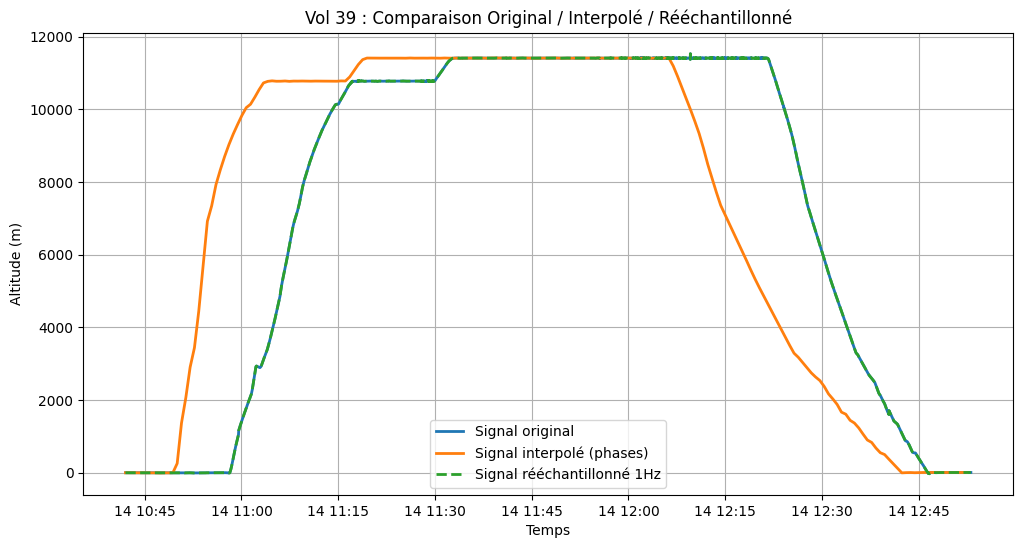

C:\Users\master\AppData\Local\Temp\ipykernel_5128\4013335284.py:68: FutureWarning:

'S' is deprecated and will be removed in a future version, please use 's' instead.



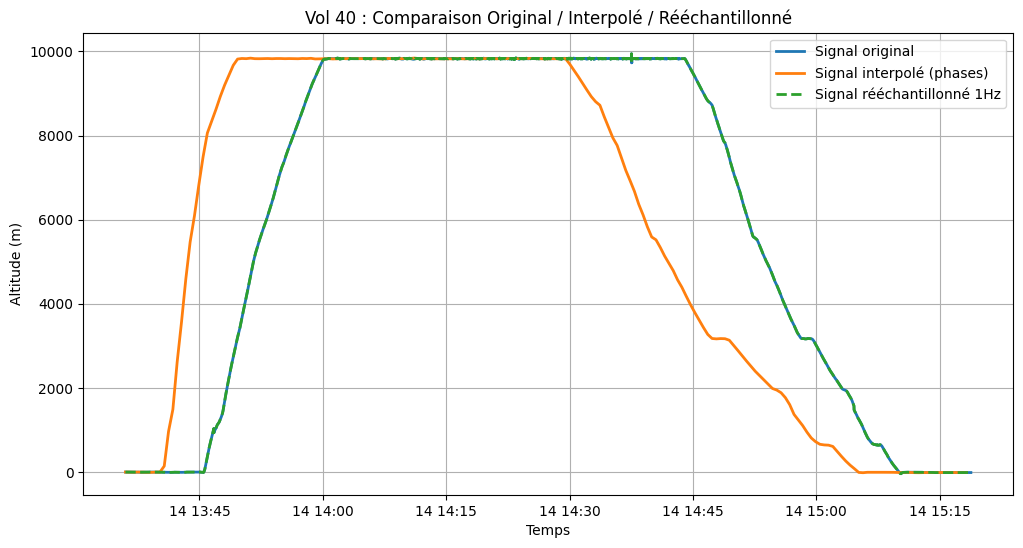

C:\Users\master\AppData\Local\Temp\ipykernel_5128\4013335284.py:68: FutureWarning:

'S' is deprecated and will be removed in a future version, please use 's' instead.



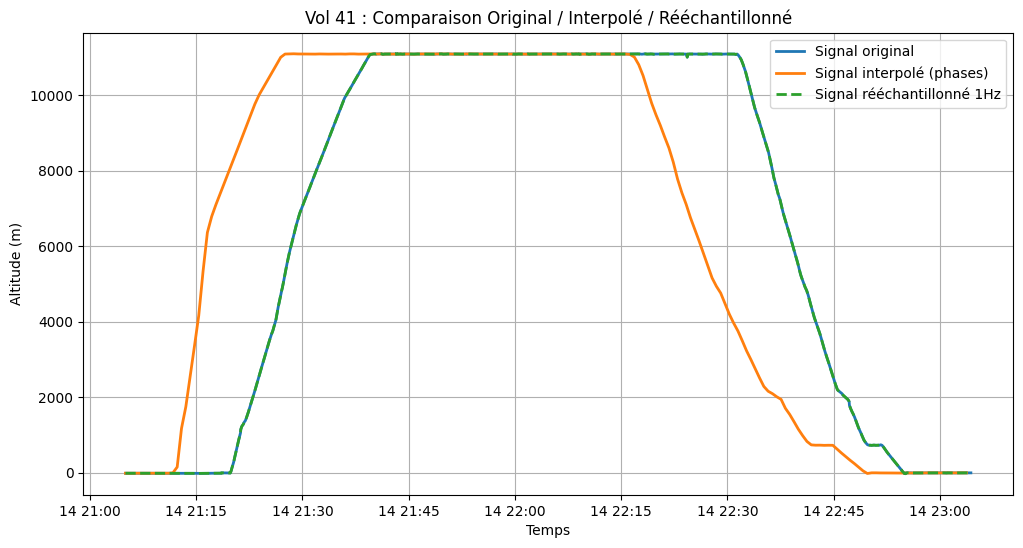

C:\Users\master\AppData\Local\Temp\ipykernel_5128\4013335284.py:68: FutureWarning:

'S' is deprecated and will be removed in a future version, please use 's' instead.



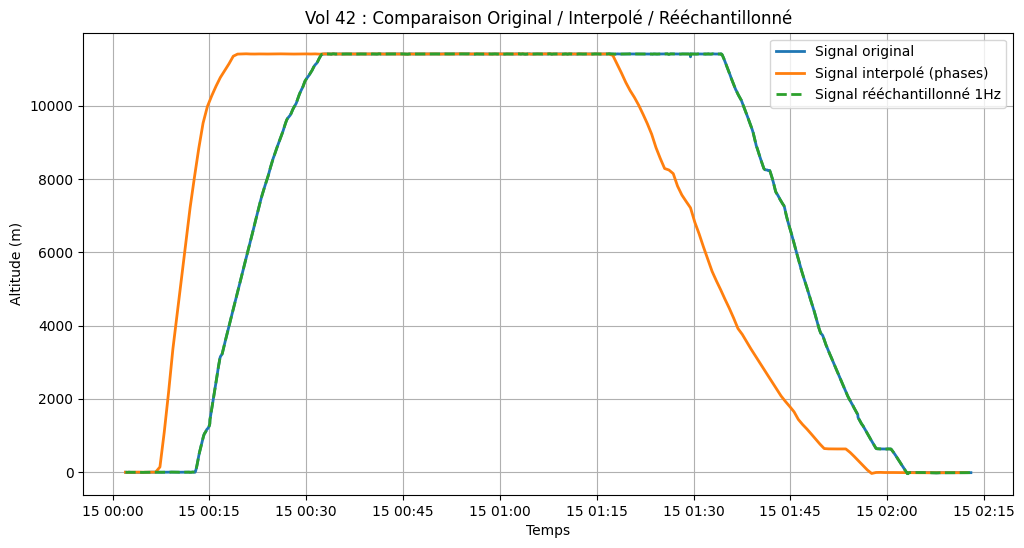

C:\Users\master\AppData\Local\Temp\ipykernel_5128\4013335284.py:68: FutureWarning:

'S' is deprecated and will be removed in a future version, please use 's' instead.



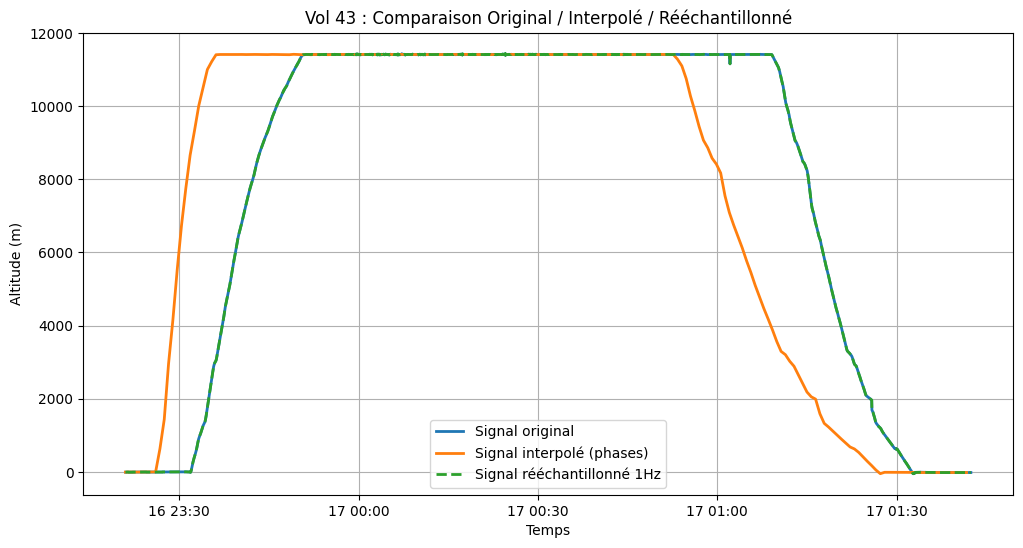

C:\Users\master\AppData\Local\Temp\ipykernel_5128\4013335284.py:68: FutureWarning:

'S' is deprecated and will be removed in a future version, please use 's' instead.



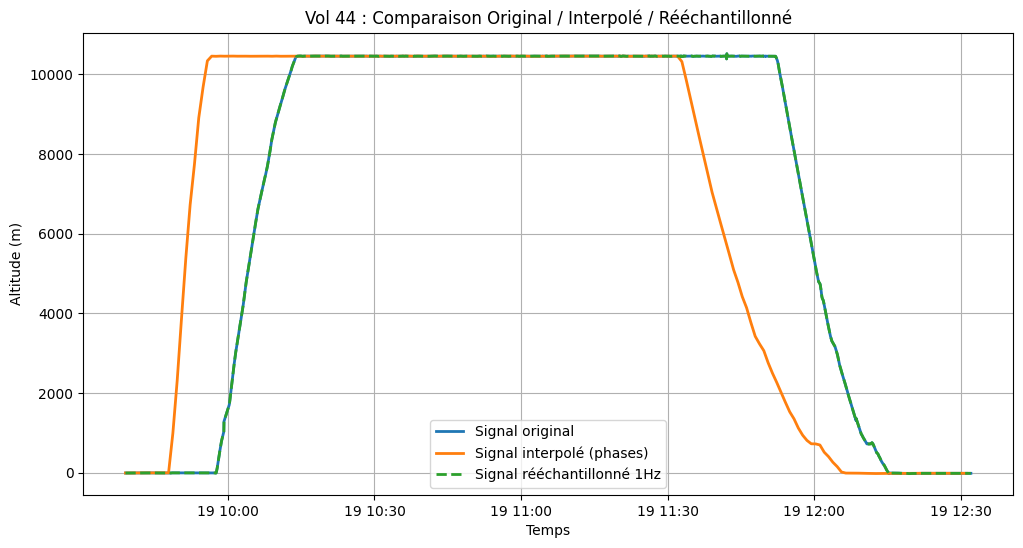

C:\Users\master\AppData\Local\Temp\ipykernel_5128\4013335284.py:68: FutureWarning:

'S' is deprecated and will be removed in a future version, please use 's' instead.



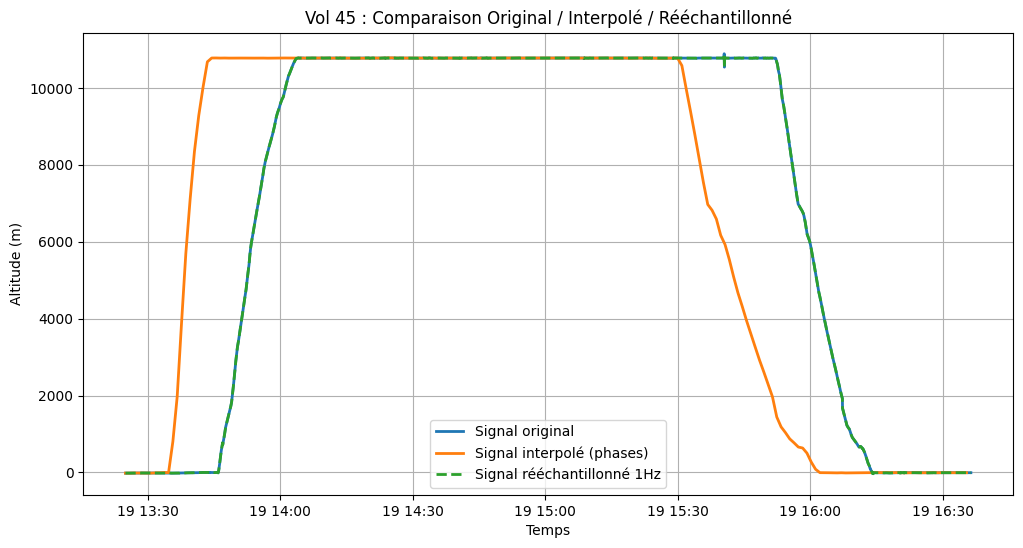

C:\Users\master\AppData\Local\Temp\ipykernel_5128\4013335284.py:68: FutureWarning:

'S' is deprecated and will be removed in a future version, please use 's' instead.



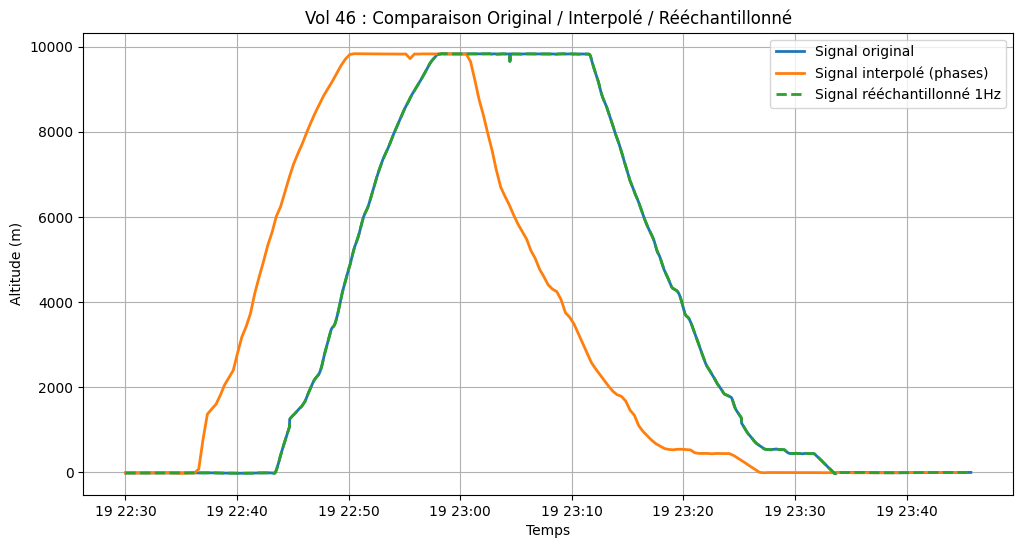

C:\Users\master\AppData\Local\Temp\ipykernel_5128\4013335284.py:68: FutureWarning:

'S' is deprecated and will be removed in a future version, please use 's' instead.



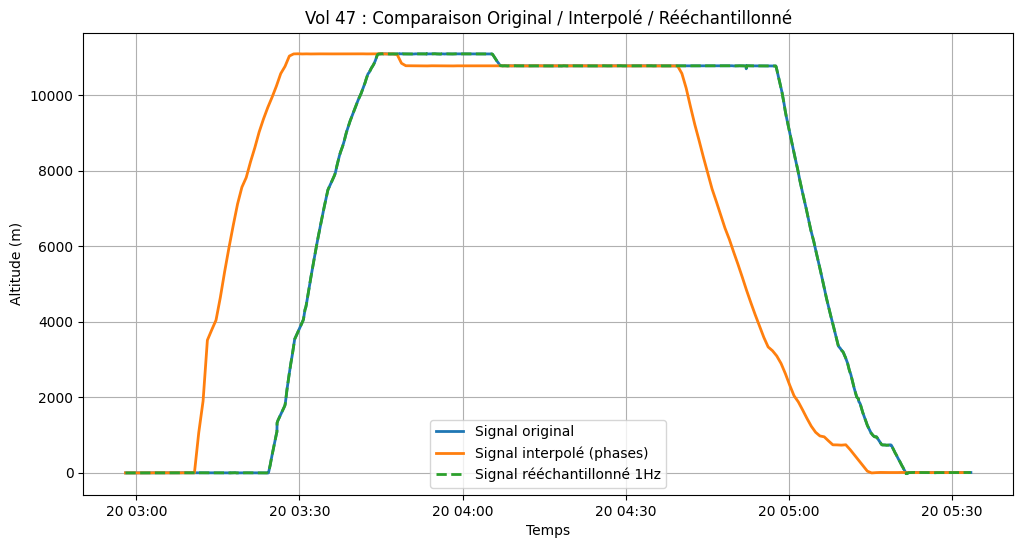

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def reechantillonner_signal(df, freq_hz=1):
    return df['ALT[m]'].resample(f'{int(1e9/freq_hz)}ns').mean().interpolate().values

def erreur_reconstruction_global(ds, R_interp, freq_hz=1):
    errors = []
    for i, df in enumerate(ds):
        y_ref = reechantillonner_signal(df, freq_hz)
        duration = df.index[-1] - df.index[0]
        interp_index = pd.date_range(start=df.index[0], periods=len(R_interp[i]),
                                     freq=f'{int(duration.total_seconds()*1e9/len(R_interp[i]))}ns')
        y_interp_rs = pd.Series(data=R_interp[i], index=interp_index).resample(f'{int(1e9/freq_hz)}ns').mean().interpolate().values
        N = min(len(y_ref), len(y_interp_rs))
        errors.append(np.sqrt(np.mean((y_ref[:N] - y_interp_rs[:N])**2)))
    return np.array(errors)

# === Interpolation phase par phase ===
def compute_points(df):
    n = len(df)
    return n//5, 2*n//5, 3*n//5, 4*n//5

NL = [20, 40, 30, 50, 60]  # Points par phase (à ajuster si besoin)
R = []
for df in ds:
    y = df['ALT[m]'].values
    index = df.index
    t1, t2, t3, t4 = compute_points(df)
    bounds = [0, t1, t2, t3, t4, len(df)-1]
    yn = (y - np.min(y)) / (np.max(y) - np.min(y))  # Normalisation
    y_interp = []
    for i in range(len(bounds) - 1):
        i0, i1 = bounds[i], bounds[i+1]
        t0, t1_ = index[i0].value, index[i1].value
        t_new = pd.to_datetime(np.linspace(t0, t1_, NL[i]))
        y_new = np.interp(t_new.astype(np.int64), index[i0:i1].astype(np.int64), yn[i0:i1])
        y_interp.extend(y_new if i == 0 else y_new[1:])
    R.append(y_interp)

R = pd.DataFrame(data=np.vstack(R).T)
R_interp = [R.iloc[:, i].values for i in range(R.shape[1])]

errors = erreur_reconstruction_global(ds, R_interp, freq_hz=1)

# === Affichage Erreurs Numériques ===
print("Erreurs de reconstruction par vol :")
for i, e in enumerate(errors):
    print(f"Vol {i+1}: erreur = {e:.4f}")
mean_error = np.nanmean(errors)
std_error = np.nanstd(errors)
print(f"\nErreur moyenne : {mean_error:.4f}, Écart-type : {std_error:.4f}")

# === Visualisation Pour Tous Les Vols ===
for idx, df_ex in enumerate(ds):
    y_original = df_ex['ALT[m]']
    t_original = df_ex.index

    # Signal interpolé (phase par phase)
    duration = t_original[-1] - t_original[0]
    interp_index = pd.date_range(start=t_original[0], periods=len(R_interp[idx]),
                                 freq=f'{int(duration.total_seconds()*1e9/len(R_interp[idx]))}ns')
    y_interp = R_interp[idx] * (y_original.max() - y_original.min()) + y_original.min()

    # Signal rééchantillonné à 1Hz
    y_resampled = reechantillonner_signal(df_ex, freq_hz=1)
    t_resampled = pd.date_range(start=t_original[0], periods=len(y_resampled),
                                freq='1S')

    plt.figure(figsize=(12,6))
    plt.plot(t_original, y_original, label='Signal original', lw=2)
    plt.plot(interp_index, y_interp, label='Signal interpolé (phases)', lw=2)
    plt.plot(t_resampled, y_resampled, label='Signal rééchantillonné 1Hz', lw=2, linestyle='--')
    plt.xlabel('Temps')
    plt.ylabel('Altitude (m)')
    plt.title(f'Vol {idx+1} : Comparaison Original / Interpolé / Rééchantillonné')
    plt.legend()
    plt.grid(True)
    plt.show()
